<a href="https://colab.research.google.com/github/AhmedB479/Pest-Prediction/blob/main/final_data_work.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ahmed Data

In [ ]:
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, VotingRegressor, BaggingRegressor, StackingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
import pandas as pd
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import warnings
from sklearn.base import clone
from joblib import Parallel, delayed

warnings.filterwarnings("ignore")

# === Load and Prepare Data ===
df = pd.read_excel("final_data.xlsx")
df.fillna(0, inplace=True)
df = df.drop(columns=['TOTAL AREA VISITED', 'TOTAL SPOTS VISITED'])

# === Define Features & Targets ===
target_cols = ['W. FLY(ABOVE ETL)', 'JASSID(ABOVE ETL)', 'THRIPS(ABOVE ETL)',
               'M.BUG(ABOVE ETL)', 'MITES(ABOVE ETL)', 'APHIDS(ABOVE ETL)',
               'DUSKY COTTON BUG(ABOVE ETL)', 'W. FLY(BELOW ETL)', 'JASSID(BELOW ETL)',
               'THRIPS(BELOW ETL)', 'MITES(BELOW ETL)', 'APHIDS(BELOW ETL)',
               'DUSKY COTTON BUG(BELOW ETL)', 'SBW(ABOVE ETL)', 'PBW(ABOVE ETL)',
               'ABW(ABOVE ETL)', 'Army Worm(ABOVE ETL)', 'SBW(BELOW ETL)',
               'PBW(BELOW ETL)', 'ABW(BELOW ETL)', 'CLCV(%SPOT)', 'CLCV(%AREA)',
               'WILT(%SPOT)', 'WILT(%AREA)']

X = df.drop(columns=target_cols)
y = df[target_cols]

random_states = [0]
all_model_results = []

# === REDUCED Parameter Grids (fewer combinations) ===
models = {
    "RandomForest": (RandomForestRegressor(), {
        'n_estimators': [100, 200],  # Reduced from [50, 100, 200]
        'max_depth': [10, None],     # Reduced from [5, 10, 15, None]
        'min_samples_split': [2, 5]
    }),
    "DecisionTree": (DecisionTreeRegressor(), {
        'max_depth': [5, 10, None],  # Reduced from [3, 5, 10, 15, None]
        'min_samples_split': [2, 5]  # Reduced from [2, 5, 10]
    }),
    "AdaBoost": (AdaBoostRegressor(), {
        'n_estimators': [100, 200],   # Reduced from [50, 100, 200]
        'learning_rate': [0.1, 1.0]  # Reduced from [0.01, 0.1, 0.5, 1.0]
    }),
    "SVM": (SVR(), {
        'C': [1, 10],                # Reduced from [0.1, 1, 10]
        'kernel': ['rbf'],           # Reduced from ['linear', 'rbf']
        'gamma': ['scale']           # Reduced from ['scale', 'auto']
    }),
    "KNN": (KNeighborsRegressor(), {
        'n_neighbors': [5, 7],       # Reduced from [3, 5, 7, 9]
        'weights': ['uniform', 'distance']
    }),
    "XGBoost": (XGBRegressor(), {
        'n_estimators': [100, 200],  # Reduced from [50, 100, 200]
        'max_depth': [3, 5],         # Reduced from [3, 5, 7]
        'learning_rate': [0.05, 0.1], # Reduced from [0.01, 0.05, 0.1]
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0]
    }),

    # === NEW ENSEMBLE METHODS ===
    "VotingRegressor": (VotingRegressor([
        ('rf', RandomForestRegressor(n_estimators=100, random_state=42)),
        ('xgb', XGBRegressor(n_estimators=100, random_state=42)),
        ('ada', AdaBoostRegressor(n_estimators=100, random_state=42))
    ]), {}),  # No hyperparameter tuning for voting - using default good params

    "BaggingRegressor": (BaggingRegressor(
        estimator=DecisionTreeRegressor(), random_state=42)
    , {
        'n_estimators': [50, 100],   # Reduced search space
        'max_samples': [0.8, 1.0]
    }),

    "StackingRegressor": (StackingRegressor(
        estimators=[
            ('rf', RandomForestRegressor(n_estimators=100, random_state=42)),
            ('xgb', XGBRegressor(n_estimators=100, random_state=42)),
            ('ada', AdaBoostRegressor(n_estimators=100, random_state=42))
        ],
        final_estimator=LinearRegression(),
        cv=3
    ), {}),  # No hyperparameter tuning for stacking
}

def tune_model(X_train, y_train, base_model, params, n_iter=5, cv=3, random_state=None):
    """Parallelized hyperparameter tuning for a single target - REDUCED n_iter"""
    best_models = []

    def fit_single_target(i, target):
        model = clone(base_model)
        if hasattr(model, 'random_state'):
            model.random_state = random_state

        # Skip hyperparameter search if no parameters to tune
        if not params:
            model.fit(X_train, y_train.iloc[:, i])
            return model

        search = RandomizedSearchCV(
            model, params, n_iter=n_iter, cv=cv,
            scoring='r2', n_jobs=1, random_state=random_state
        )
        try:
            search.fit(X_train, y_train.iloc[:, i])
            return search.best_estimator_
        except:
            model.fit(X_train, y_train.iloc[:, i])
            return model

    # Parallel execution
    best_models = Parallel(n_jobs=-1)(
        delayed(fit_single_target)(i, target)
        for i, target in enumerate(y_train.columns)
    )

    return best_models

for model_name, (base_model, param_grid) in models.items():
    print(f"\n🚀 Processing: {model_name}")
    model_results = []

    for rnd in random_states:
        print(f"  🔁 Random State: {rnd}")
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.3, random_state=rnd
        )

        # Tune models in parallel (reduced from n_iter=10 to n_iter=5)
        estimators = tune_model(
            X_train, y_train, base_model, param_grid,
            n_iter=5, cv=3, random_state=rnd  # REDUCED from n_iter=10
        )

        # Create multi-output model
        model = MultiOutputRegressor(base_model)
        model.estimators_ = estimators

        # Predict and evaluate
        y_pred = model.predict(X_test)
        y_pred = np.clip(np.round(y_pred, 1), 0, None)

        metrics = []
        for i, col in enumerate(y_test.columns):
            r2 = r2_score(y_test[col], y_pred[:, i])
            mae = mean_absolute_error(y_test[col], y_pred[:, i])
            rmse = np.sqrt(mean_squared_error(y_test[col], y_pred[:, i]))
            metrics.append([col, r2, mae, rmse])

        metrics_df = pd.DataFrame(metrics, columns=["Target", "R² Score", "MAE", "RMSE"])
        metrics_df["RandomState"] = rnd
        model_results.append(metrics_df)

    # Save and store results
    final_df = pd.concat(model_results, ignore_index=True)
    final_df["Model"] = model_name
    all_model_results.append(final_df)
    final_df.to_csv(f"{model_name}_results.csv", index=False)
    print(f"✅ Saved {model_name} results | Shape: {final_df.shape}")

# Combine all results
combined = pd.concat(all_model_results, ignore_index=True)
combined.to_csv("all_model_results.csv", index=False)

# === ENSEMBLE ANALYSIS ===
print("\n🔥 All models completed! Generating ensemble performance summary...")

# Calculate average performance by model
summary = combined.groupby('Model')[['R² Score', 'MAE', 'RMSE']].agg(['mean', 'std']).round(4)
summary.to_csv("model_performance_summary.csv")

print("\n📊 Model Performance Summary:")
print(summary.sort_values(('R² Score', 'mean'), ascending=False))

print("\n🏆 Best performing models by R² Score:")
best_models = combined.groupby('Model')['R² Score'].mean().sort_values(ascending=False)
print(best_models.head(3))

print("\n✨ Results saved to CSV files!")


🚀 Processing: RandomForest
  🔁 Random State: 0


KeyboardInterrupt: 

In [ ]:
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, VotingRegressor, BaggingRegressor, StackingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
import pandas as pd
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import warnings
from joblib import Parallel, delayed

warnings.filterwarnings("ignore")

# === Load and Prepare Data ===
df = pd.read_excel("final_data.xlsx")
df.fillna(0, inplace=True)
df = df.drop(columns=['TOTAL AREA VISITED', 'TOTAL SPOTS VISITED'])

# === Define Features & Targets ===
target_cols = ['W. FLY(ABOVE ETL)', 'JASSID(ABOVE ETL)', 'THRIPS(ABOVE ETL)',
               'M.BUG(ABOVE ETL)', 'MITES(ABOVE ETL)', 'APHIDS(ABOVE ETL)',
               'DUSKY COTTON BUG(ABOVE ETL)', 'W. FLY(BELOW ETL)', 'JASSID(BELOW ETL)',
               'THRIPS(BELOW ETL)', 'MITES(BELOW ETL)', 'APHIDS(BELOW ETL)',
               'DUSKY COTTON BUG(BELOW ETL)', 'SBW(ABOVE ETL)', 'PBW(ABOVE ETL)',
               'ABW(ABOVE ETL)', 'Army Worm(ABOVE ETL)', 'SBW(BELOW ETL)',
               'PBW(BELOW ETL)', 'ABW(BELOW ETL)', 'CLCV(%SPOT)', 'CLCV(%AREA)',
               'WILT(%SPOT)', 'WILT(%AREA)']

X = df.drop(columns=target_cols)
y = df[target_cols]

random_states = [0, 21, 42, 77, 101]
all_model_results = []

# === Simplified Models without Hyperparameter Tuning ===
models = {
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42),
    "DecisionTree": DecisionTreeRegressor(random_state=42),
    "AdaBoost": AdaBoostRegressor(n_estimators=100, random_state=42),
    "SVM": SVR(),
    "KNN": KNeighborsRegressor(),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "VotingRegressor": VotingRegressor([
        ('rf', RandomForestRegressor(n_estimators=100, random_state=42)),
        ('xgb', XGBRegressor(n_estimators=100, random_state=42)),
        ('ada', AdaBoostRegressor(n_estimators=100, random_state=42))
    ]),
    "BaggingRegressor": BaggingRegressor(
        estimator=DecisionTreeRegressor(),
        n_estimators=50,
        random_state=42
    ),
    "StackingRegressor": StackingRegressor(
        estimators=[
            ('rf', RandomForestRegressor(n_estimators=100, random_state=42)),
            ('xgb', XGBRegressor(n_estimators=100, random_state=42)),
            ('ada', AdaBoostRegressor(n_estimators=100, random_state=42))
        ],
        final_estimator=LinearRegression(),
        cv=3
    )
}

def train_predict_single_target(model, X_train, y_train, X_test):
    """Train and predict for a single target"""
    model.fit(X_train, y_train)
    return model.predict(X_test)

for model_name, base_model in models.items():
    print(f"\n🚀 Processing: {model_name}")
    model_results = []

    for rnd in random_states:
        print(f"  🔁 Random State: {rnd}")
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.3, random_state=rnd
        )

        # Train models in parallel
        predictions = Parallel(n_jobs=-1)(
            delayed(train_predict_single_target)(
                clone(base_model), X_train, y_train[col], X_test
            )
            for col in y_train.columns
        )

        # Convert predictions to numpy array
        y_pred = np.array(predictions).T
        y_pred = np.clip(np.round(y_pred, 1), 0, None)

        metrics = []
        for i, col in enumerate(y_test.columns):
            r2 = r2_score(y_test[col], y_pred[:, i])
            mae = mean_absolute_error(y_test[col], y_pred[:, i])
            rmse = np.sqrt(mean_squared_error(y_test[col], y_pred[:, i]))
            metrics.append([col, r2, mae, rmse])

        metrics_df = pd.DataFrame(metrics, columns=["Target", "R² Score", "MAE", "RMSE"])
        metrics_df["RandomState"] = rnd
        model_results.append(metrics_df)

    # Save and store results
    final_df = pd.concat(model_results, ignore_index=True)
    final_df["Model"] = model_name
    all_model_results.append(final_df)
    final_df.to_csv(f"{model_name}_results.csv", index=False)
    print(f"✅ Saved {model_name} results | Shape: {final_df.shape}")

# Combine all results
combined = pd.concat(all_model_results, ignore_index=True)
combined.to_csv("all_model_results.csv", index=False)

# === Performance Analysis ===
print("\n🔥 All models completed! Generating performance summary...")

# Calculate average performance by model
summary = combined.groupby('Model')[['R² Score', 'MAE', 'RMSE']].agg(['mean', 'std']).round(4)
summary.to_csv("model_performance_summary.csv")

print("\n📊 Model Performance Summary:")
print(summary.sort_values(('R² Score', 'mean'), ascending=False))

print("\n🏆 Best performing models by R² Score:")
best_models = combined.groupby('Model')['R² Score'].mean().sort_values(ascending=False)
print(best_models.head(3))

print("\n✨ Results saved to CSV files!")


🚀 Processing: RandomForest
  🔁 Random State: 0
  🔁 Random State: 21
  🔁 Random State: 42
  🔁 Random State: 77
  🔁 Random State: 101
✅ Saved RandomForest results | Shape: (120, 6)

🚀 Processing: DecisionTree
  🔁 Random State: 0
  🔁 Random State: 21
  🔁 Random State: 42
  🔁 Random State: 77
  🔁 Random State: 101
✅ Saved DecisionTree results | Shape: (120, 6)

🚀 Processing: AdaBoost
  🔁 Random State: 0
  🔁 Random State: 21
  🔁 Random State: 42
  🔁 Random State: 77
  🔁 Random State: 101
✅ Saved AdaBoost results | Shape: (120, 6)

🚀 Processing: SVM
  🔁 Random State: 0
  🔁 Random State: 21
  🔁 Random State: 42
  🔁 Random State: 77
  🔁 Random State: 101
✅ Saved SVM results | Shape: (120, 6)

🚀 Processing: KNN
  🔁 Random State: 0
  🔁 Random State: 21
  🔁 Random State: 42
  🔁 Random State: 77
  🔁 Random State: 101
✅ Saved KNN results | Shape: (120, 6)

🚀 Processing: XGBoost
  🔁 Random State: 0
  🔁 Random State: 21
  🔁 Random State: 42
  🔁 Random State: 77
  🔁 Random State: 101
✅ Saved XGBoost 

In [ ]:
from sklearn.base import clone
from sklearn.model_selection import train_test_split
import os
from joblib import dump


warnings.filterwarnings("ignore")

# === Load and Prepare Data ===
df = pd.read_excel("final_data.xlsx")
df.fillna(0, inplace=True)
df = df.drop(columns=['TOTAL AREA VISITED', 'TOTAL SPOTS VISITED'])

# === Define Features & Targets ===
target_cols = ['W. FLY(ABOVE ETL)', 'JASSID(ABOVE ETL)', 'THRIPS(ABOVE ETL)',
               'M.BUG(ABOVE ETL)', 'MITES(ABOVE ETL)', 'APHIDS(ABOVE ETL)',
               'DUSKY COTTON BUG(ABOVE ETL)', 'W. FLY(BELOW ETL)', 'JASSID(BELOW ETL)',
               'THRIPS(BELOW ETL)', 'MITES(BELOW ETL)', 'APHIDS(BELOW ETL)',
               'DUSKY COTTON BUG(BELOW ETL)', 'SBW(ABOVE ETL)', 'PBW(ABOVE ETL)',
               'ABW(ABOVE ETL)', 'Army Worm(ABOVE ETL)', 'SBW(BELOW ETL)',
               'PBW(BELOW ETL)', 'ABW(BELOW ETL)', 'CLCV(%SPOT)', 'CLCV(%AREA)',
               'WILT(%SPOT)', 'WILT(%AREA)']

X = df.drop(columns=target_cols)
y = df[target_cols]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Pick the best model
best_model_name = "StackingRegressor"
best_model = clone(models[best_model_name])

# Train separately for each target (multi-output training)
trained_models = {}
for target in y.columns:
    model = clone(best_model)
    model.fit(X_train, y_train[target])  # Train on training set only
    trained_models[target] = model

# Define the folder name
model_dir = "best_models_train_split"

# Create the directory if it doesn't exist
os.makedirs(model_dir, exist_ok=True)

# Save models to the folder
for target, model in trained_models.items():
    filename = f"{model_dir}/best_model_{best_model_name}_{target}.joblib"
    dump(model, filename)

print(f"✅ All models saved to '{model_dir}/'")

print("✅ Models trained on training data.")

✅ All models saved to 'best_models_train_split/'
✅ Models trained on training data.


In [ ]:
import os
import shap
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lime.lime_tabular import LimeTabularExplainer
from sklearn.inspection import permutation_importance
from xgboost import XGBRegressor
import seaborn as sns
from matplotlib.gridspec import GridSpec

# Set matplotlib style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")



X = X_test
y = y_test

# === Define paths ===
model_dir = "best_models_train_split"
output_dir = "model_interpretation_train_test_outputs"
os.makedirs(output_dir, exist_ok=True)

# === LIME Explainer Setup (Global) ===
lime_explainer = LimeTabularExplainer(
    training_data=X.values,
    feature_names=X.columns.tolist(),
    mode='regression',
    random_state=42
)

# === Storage for all results ===
all_pfi_results = {}
all_shap_results = {}
all_lime_results = {}

# === Loop through all target models ===
for target in target_cols:
    print(f"\n🔍 Interpreting model for target: {target}")
    model_path = os.path.join(model_dir, f"best_model_StackingRegressor_{target}.joblib")
    if not os.path.exists(model_path):
        print(f"⚠️ Skipping missing model for: {target}")
        continue

    model = joblib.load(model_path)

    # === 1. Permutation Feature Importance (PFI) ===
    print(f"  ➤ Calculating PFI...")
    pfi_result = permutation_importance(model, X, y[target], n_repeats=10, random_state=42)
    sorted_idx = pfi_result.importances_mean.argsort()[::-1]

    # Store PFI results
    all_pfi_results[target] = {
        'importances': pfi_result.importances_mean,
        'features': X.columns,
        'sorted_idx': sorted_idx
    }

    # === 2. SHAP (using XGBoost only, as surrogate model) ===
    print(f"  ➤ Training XGBoost for SHAP...")
    xgb_model = XGBRegressor(n_estimators=100, random_state=42)
    xgb_model.fit(X, y[target])

    explainer = shap.Explainer(xgb_model, X)
    shap_values = explainer(X)

    # Store SHAP results
    all_shap_results[target] = {
        'shap_values': shap_values,
        'feature_importance': np.abs(shap_values.values).mean(0)
    }

    # === 3. LIME Explanation (on 1st sample) ===
    print(f"  ➤ Running LIME on sample 0...")
    sample_idx = 0
    instance = X.iloc[sample_idx].values

    lime_exp = lime_explainer.explain_instance(
        data_row=instance,
        predict_fn=model.predict
    )

    # Extract LIME feature importance
    lime_values = lime_exp.as_list()
    lime_features = [item[0] for item in lime_values]
    lime_importance = [item[1] for item in lime_values]

    all_lime_results[target] = {
        'features': lime_features,
        'importance': lime_importance
    }

print("\n✅ All interpretation calculations completed!")

# === VISUALIZATION FUNCTIONS ===

def plot_individual_pfi(target_name, max_features=15):
    """Plot PFI for a single target"""
    data = all_pfi_results[target_name]
    top_idx = data['sorted_idx'][:max_features]

    plt.figure(figsize=(12, 8))
    plt.barh(range(len(top_idx)), data['importances'][top_idx])
    plt.yticks(range(len(top_idx)), data['features'][top_idx])
    plt.xlabel('Permutation Importance')
    plt.title(f'Permutation Feature Importance - {target_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

def plot_individual_shap(target_name, max_features=15):
    """Plot SHAP for a single target"""
    data = all_shap_results[target_name]
    sorted_idx = np.argsort(data['feature_importance'])[::-1][:max_features]

    plt.figure(figsize=(12, 8))
    plt.barh(range(len(sorted_idx)), data['feature_importance'][sorted_idx])
    plt.yticks(range(len(sorted_idx)), X.columns[sorted_idx])
    plt.xlabel('Mean |SHAP Value|')
    plt.title(f'SHAP Feature Importance - {target_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

def plot_individual_lime(target_name, max_features=15):
    """Plot LIME for a single target"""
    data = all_lime_results[target_name]
    # Sort by absolute importance
    sorted_pairs = sorted(zip(data['features'], data['importance']),
                         key=lambda x: abs(x[1]), reverse=True)[:max_features]

    features, importance = zip(*sorted_pairs)
    colors = ['red' if imp < 0 else 'blue' for imp in importance]

    plt.figure(figsize=(12, 8))
    plt.barh(range(len(features)), importance, color=colors)
    plt.yticks(range(len(features)), features)
    plt.xlabel('LIME Feature Importance')
    plt.title(f'LIME Feature Importance - {target_name} (Sample 0)')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

def plot_comparison_heatmap(method='pfi', max_features=10):
    """Create heatmap comparing feature importance across all targets"""
    if method == 'pfi':
        data_dict = all_pfi_results
        title = 'Permutation Feature Importance Across All Targets'
        ylabel = 'Permutation Importance'
    elif method == 'shap':
        data_dict = all_shap_results
        title = 'SHAP Feature Importance Across All Targets'
        ylabel = 'Mean |SHAP Value|'

    # Get top features across all targets
    all_features = set()
    for target_data in data_dict.values():
        if method == 'pfi':
            top_idx = target_data['sorted_idx'][:max_features]
            all_features.update(target_data['features'][top_idx])
        elif method == 'shap':
            sorted_idx = np.argsort(target_data['feature_importance'])[::-1][:max_features]
            all_features.update(X.columns[sorted_idx])

    # Create matrix
    feature_list = list(all_features)[:max_features]
    matrix = np.zeros((len(feature_list), len(data_dict)))

    for j, (target, target_data) in enumerate(data_dict.items()):
        for i, feature in enumerate(feature_list):
            if method == 'pfi':
                feature_idx = np.where(target_data['features'] == feature)[0]
                if len(feature_idx) > 0:
                    matrix[i, j] = target_data['importances'][feature_idx[0]]
            elif method == 'shap':
                feature_idx = np.where(X.columns == feature)[0]
                if len(feature_idx) > 0:
                    matrix[i, j] = target_data['feature_importance'][feature_idx[0]]

    plt.figure(figsize=(16, 10))
    sns.heatmap(matrix,
                xticklabels=list(data_dict.keys()),
                yticklabels=feature_list,
                annot=True,
                fmt='.3f',
                cmap='viridis',
                cbar_kws={'label': ylabel})
    plt.title(title)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

def plot_top_features_summary(max_features=10):
    """Plot top features across all methods for comparison"""
    fig = plt.figure(figsize=(20, 12))
    gs = GridSpec(2, 2, figure=fig)

    # Get most important features from each method
    pfi_features = {}
    shap_features = {}

    for target in all_pfi_results.keys():
        pfi_data = all_pfi_results[target]
        top_idx = pfi_data['sorted_idx'][:max_features]
        for idx in top_idx:
            feature = pfi_data['features'][idx]
            if feature not in pfi_features:
                pfi_features[feature] = []
            pfi_features[feature].append(pfi_data['importances'][idx])

    for target in all_shap_results.keys():
        shap_data = all_shap_results[target]
        sorted_idx = np.argsort(shap_data['feature_importance'])[::-1][:max_features]
        for idx in sorted_idx:
            feature = X.columns[idx]
            if feature not in shap_features:
                shap_features[feature] = []
            shap_features[feature].append(shap_data['feature_importance'][idx])

    # Average importance across targets
    pfi_avg = {k: np.mean(v) for k, v in pfi_features.items()}
    shap_avg = {k: np.mean(v) for k, v in shap_features.items()}

    # Sort and plot
    pfi_sorted = sorted(pfi_avg.items(), key=lambda x: x[1], reverse=True)[:max_features]
    shap_sorted = sorted(shap_avg.items(), key=lambda x: x[1], reverse=True)[:max_features]

    # PFI plot
    ax1 = fig.add_subplot(gs[0, 0])
    features, importance = zip(*pfi_sorted)
    ax1.barh(range(len(features)), importance)
    ax1.set_yticks(range(len(features)))
    ax1.set_yticklabels(features)
    ax1.set_xlabel('Average Permutation Importance')
    ax1.set_title('Top Features - PFI (Average across targets)')
    ax1.invert_yaxis()

    # SHAP plot
    ax2 = fig.add_subplot(gs[0, 1])
    features, importance = zip(*shap_sorted)
    ax2.barh(range(len(features)), importance)
    ax2.set_yticks(range(len(features)))
    ax2.set_yticklabels(features)
    ax2.set_xlabel('Average SHAP Importance')
    ax2.set_title('Top Features - SHAP (Average across targets)')
    ax2.invert_yaxis()

    # Combined comparison
    ax3 = fig.add_subplot(gs[1, :])
    all_features = set(pfi_avg.keys()) | set(shap_avg.keys())
    combined_data = []

    for feature in all_features:
        pfi_val = pfi_avg.get(feature, 0)
        shap_val = shap_avg.get(feature, 0)
        combined_data.append((feature, pfi_val, shap_val))

    combined_data = sorted(combined_data, key=lambda x: x[1] + x[2], reverse=True)[:max_features]

    features, pfi_vals, shap_vals = zip(*combined_data)
    x = np.arange(len(features))
    width = 0.35

    ax3.bar(x - width/2, pfi_vals, width, label='PFI', alpha=0.7)
    ax3.bar(x + width/2, shap_vals, width, label='SHAP', alpha=0.7)
    ax3.set_xlabel('Features')
    ax3.set_ylabel('Importance')
    ax3.set_title('Feature Importance Comparison - PFI vs SHAP')
    ax3.set_xticks(x)
    ax3.set_xticklabels(features, rotation=45, ha='right')
    ax3.legend()

    plt.tight_layout()
    plt.show()

# === INTERACTIVE MENU ===
def display_menu():
    print("\n" + "="*60)
    print("🔍 MODEL INTERPRETATION VISUALIZATIONS")
    print("="*60)
    print("1. Individual PFI plots")
    print("2. Individual SHAP plots")
    print("3. Individual LIME plots")
    print("4. PFI Heatmap (all targets)")
    print("5. SHAP Heatmap (all targets)")
    print("6. Top Features Summary (PFI vs SHAP)")
    print("7. All visualizations")
    print("0. Exit")
    print("="*60)

def main_menu():
    while True:
        display_menu()
        choice = input("\nEnter your choice (0-7): ").strip()

        if choice == '0':
            print("👋 Goodbye!")
            break
        elif choice == '1':
            print(f"\nAvailable targets: {list(all_pfi_results.keys())}")
            target = input("Enter target name: ").strip()
            if target in all_pfi_results:
                plot_individual_pfi(target)
            else:
                print("❌ Target not found!")
        elif choice == '2':
            print(f"\nAvailable targets: {list(all_shap_results.keys())}")
            target = input("Enter target name: ").strip()
            if target in all_shap_results:
                plot_individual_shap(target)
            else:
                print("❌ Target not found!")
        elif choice == '3':
            print(f"\nAvailable targets: {list(all_lime_results.keys())}")
            target = input("Enter target name: ").strip()
            if target in all_lime_results:
                plot_individual_lime(target)
            else:
                print("❌ Target not found!")
        elif choice == '4':
            plot_comparison_heatmap('pfi')
        elif choice == '5':
            plot_comparison_heatmap('shap')
        elif choice == '6':
            plot_top_features_summary()
        elif choice == '7':
            print("\n🎨 Showing all visualizations...")
            plot_comparison_heatmap('pfi')
            plot_comparison_heatmap('shap')
            plot_top_features_summary()
        else:
            print("❌ Invalid choice! Please try again.")

# === RUN INTERACTIVE MENU ===
if __name__ == "__main__":
    main_menu()


🔍 Interpreting model for target: W. FLY(ABOVE ETL)
  ➤ Calculating PFI...


KeyboardInterrupt: 

                         Target      R2      MAE       MSE     RMSE  Accuracy  \
0             W. FLY(ABOVE ETL)  0.8228   3.8921   47.4288   6.8869    0.8642   
1             JASSID(ABOVE ETL)  0.6272   3.2348   31.0188   5.5695    0.7905   
2             THRIPS(ABOVE ETL)  0.5936   1.4766   10.2520   3.2019    0.7737   
3              M.BUG(ABOVE ETL)  0.8423   2.5482   25.7833   5.0777    0.8381   
4              MITES(ABOVE ETL)  0.0043   0.0130    0.0239   0.1544    0.9979   
5             APHIDS(ABOVE ETL) -0.0008   0.0223    0.0677   0.2602    0.9976   
6   DUSKY COTTON BUG(ABOVE ETL)  0.5636   0.9464    8.6809   2.9463    0.8632   
7             W. FLY(BELOW ETL)  0.8265   9.7338  208.3675  14.4349    0.9208   
8             JASSID(BELOW ETL)  0.8469   9.5190  206.9991  14.3875    0.8978   
9             THRIPS(BELOW ETL)  0.7547  12.4177  350.1948  18.7135    0.9029   
10             MITES(BELOW ETL)  0.3531   1.8431   21.3499   4.6206    0.6324   
11            APHIDS(BELOW E

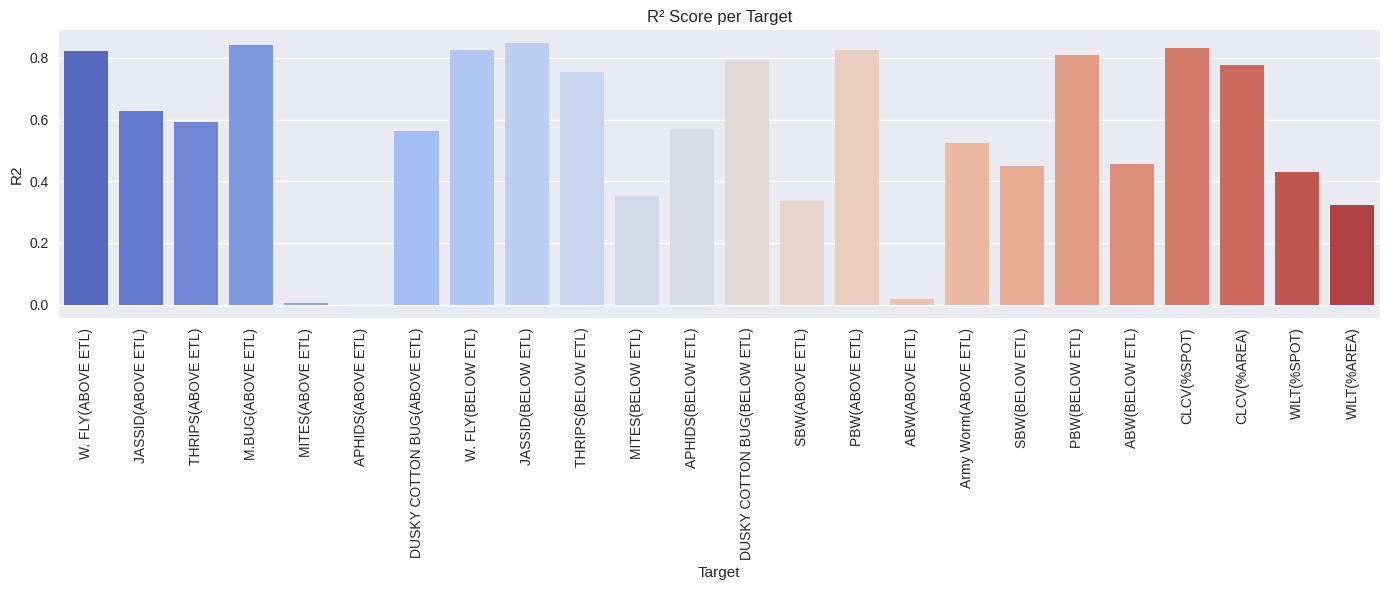

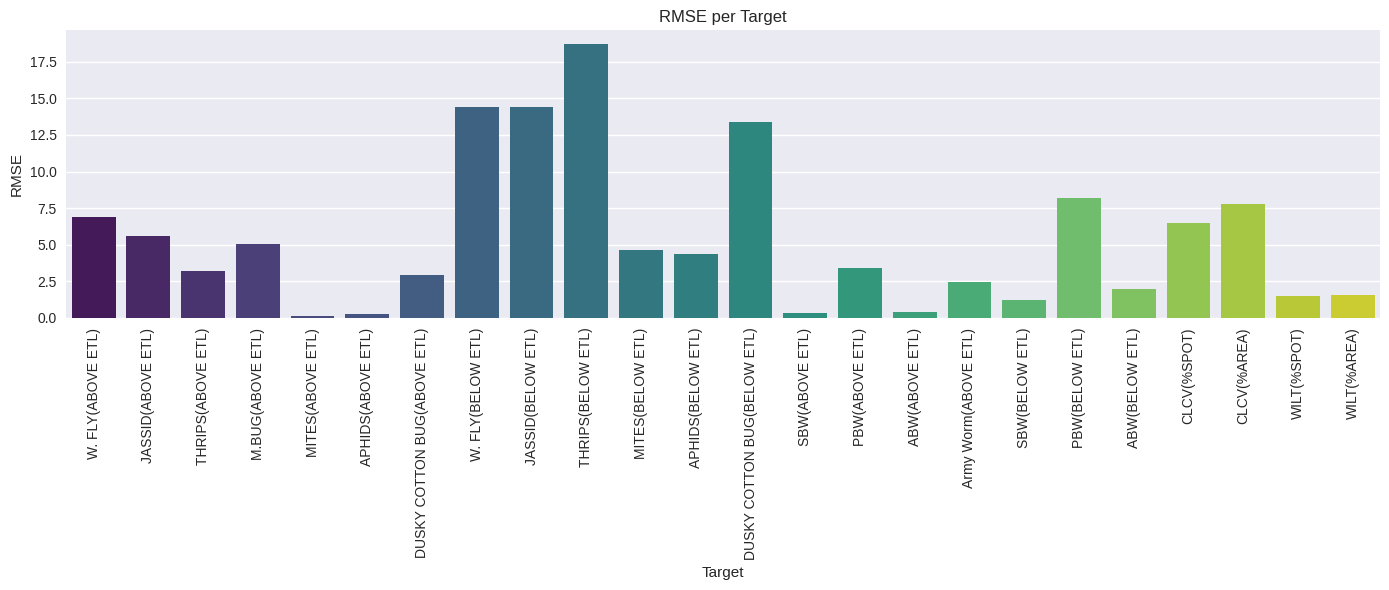

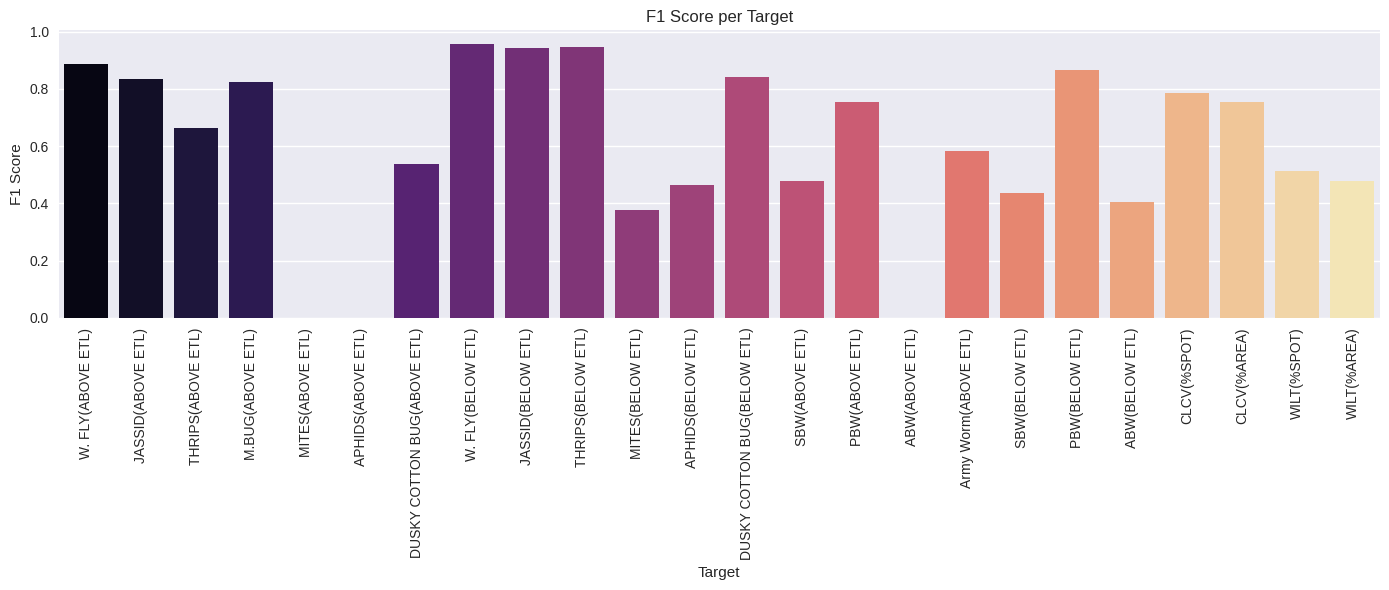

,Actual_W. FLY(ABOVE ETL),Actual_JASSID(ABOVE ETL),Actual_THRIPS(ABOVE ETL),Actual_M.BUG(ABOVE ETL),Actual_MITES(ABOVE ETL),Actual_APHIDS(ABOVE ETL),Actual_DUSKY COTTON BUG(ABOVE ETL),Actual_W. FLY(BELOW ETL),Actual_JASSID(BELOW ETL),Actual_THRIPS(BELOW ETL),...,Predicted_PBW(ABOVE ETL),Predicted_ABW(ABOVE ETL),Predicted_Army Worm(ABOVE ETL),Predicted_SBW(BELOW ETL),Predicted_PBW(BELOW ETL),Predicted_ABW(BELOW ETL),Predicted_CLCV(%SPOT),Predicted_CLCV(%AREA),Predicted_WILT(%SPOT),Predicted_WILT(%AREA)
0,29.4,52.9,3.9,23.5,0.0,0.0,11.8,70.6,47.1,96.1,...,2.646976,0.018753,4.169630,0.012566,16.428693,0.075857,57.644022,60.628899,1.099635,0.824228
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.037982,0.011821,-0.088619,-0.004986,-0.295890,-0.031333,0.043301,-0.014898,0.014877,0.058239
2,9.6,11.1,3.7,3.0,0.0,0.0,0.0,90.4,88.9,96.3,...,0.523401,0.004545,-0.146162,0.008098,20.710651,-0.057708,0.334960,0.661400,0.002740,0.097669
3,44.4,9.3,0.0,7.4,0.0,0.0,0.0,55.6,90.7,22.2,...,1.165933,0.004843,0.823277,0.032594,16.099627,0.148119,42.258690,40.742622,3.600539,2.929088
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.104697,0.009823,0.333616,0.003975,-0.143779,-0.046007,-0.015875,0.098980,0.010231,0.050799
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2911,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.7,0.0,26.9,...,0.028234,0.003727,1.436324,0.011722,-0.317283,-0.053490,-0.045129,0.109983,0.029072,0.046817
2912,56.0,2.0,0.0,52.0,0.0,0.0,0.0,44.0,98.0,100.0,...,26.639071,0.030431,1.872456,1.030585,38.134767,0.301303,20.986897,21.135942,1.766790,0.465811
2913,25.9,15.5,1.7,8.6,0.0,0.0,0.0,74.1,74.1,100.0,...,0.388547,0.093809,0.177255,0.427730,7.049712,0.300013,9.280225,7.832845,3.024233,3.052801
2914,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0,20.0,20.0,...,0.241271,0.025405,0.538153,0.017510,1.140297,-0.056139,0.367329,0.211150,0.005971,0.056394


In [ ]:
import os
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    precision_score, recall_score, f1_score, roc_auc_score, accuracy_score
)
from sklearn.preprocessing import Binarizer

# === Load your test data ===
# Make sure X_test and y_test are already defined
X = X_test
y = y_test

model_dir = "best_models_train_split"
y_pred_all = pd.DataFrame()
y_test_all = pd.DataFrame()

# === Evaluation results holder ===
evaluation_results = []

for target in y.columns:
    model_path = os.path.join(model_dir, f"best_model_StackingRegressor_{target}.joblib")
    if not os.path.exists(model_path):
        print(f"Skipping missing model for: {target}")
        continue

    model = joblib.load(model_path)
    y_pred = model.predict(X)
    y_true = y[target].values

    y_test_all[target] = y_true
    y_pred_all[target] = y_pred

    # Basic metrics
    mse = mean_squared_error(y_true, y_pred)
    rmse = mse ** 0.5
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    # Binary conversion (if applicable)
    y_true_bin = Binarizer(threshold=0.5).fit_transform(y_true.reshape(-1, 1)).ravel()
    y_pred_bin = Binarizer(threshold=0.5).fit_transform(y_pred.reshape(-1, 1)).ravel()

    try:
        acc = accuracy_score(y_true_bin, y_pred_bin)
        prec = precision_score(y_true_bin, y_pred_bin)
        rec = recall_score(y_true_bin, y_pred_bin)
        f1 = f1_score(y_true_bin, y_pred_bin)
        roc = roc_auc_score(y_true_bin, y_pred)
    except:
        acc = prec = rec = f1 = roc = None

    evaluation_results.append([
        target, r2, mae, mse, rmse, acc, prec, rec, f1, roc
    ])

# === Convert to DataFrame ===
columns = ['Target', 'R2', 'MAE', 'MSE', 'RMSE', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']
eval_df = pd.DataFrame(evaluation_results, columns=columns).round(4)
print(eval_df)

# === Plotting ===
plt.figure(figsize=(14, 6))
sns.barplot(data=eval_df, x='Target', y='R2', palette='coolwarm')
plt.title('R² Score per Target')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
sns.barplot(data=eval_df, x='Target', y='RMSE', palette='viridis')
plt.title('RMSE per Target')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
sns.barplot(data=eval_df, x='Target', y='F1 Score', palette='magma')
plt.title('F1 Score per Target')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# === Show predictions side-by-side with actuals ===
comparison_df = pd.concat([y_test_all, y_pred_all], axis=1, keys=['Actual', 'Predicted'])
comparison_df = comparison_df.swaplevel(axis=1)
comparison_df.columns = [f"{col[1]}_{col[0]}" for col in comparison_df.columns]
comparison_df.reset_index(drop=True, inplace=True)

# Show the first 10 rows of the side-by-side table
comparison_df


In [ ]:
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)

# === Extended Evaluation Metrics for Best Models ===
eval_results = []

for target in target_cols:
    model_path = os.path.join(model_dir, f"best_model_StackingRegressor_{target}.joblib")
    if not os.path.exists(model_path):
        print(f"⚠️ Model not found for {target}, skipping...")
        continue

    model = joblib.load(model_path)
    y_true = y_test[target]
    y_pred = model.predict(X_test)

    # Regression metrics
    r2 = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = mse ** 0.5
    mae = mean_absolute_error(y_true, y_pred)

    # Binarize for classification metrics
    try:
        y_true_bin = (y_true > 0.5).astype(int)
        y_pred_bin = (y_pred > 0.5).astype(int)
        acc = accuracy_score(y_true_bin, y_pred_bin)
        prec = precision_score(y_true_bin, y_pred_bin, zero_division=0)
        rec = recall_score(y_true_bin, y_pred_bin, zero_division=0)
        f1 = f1_score(y_true_bin, y_pred_bin, zero_division=0)
        roc = roc_auc_score(y_true_bin, y_pred)
    except Exception as e:
        acc = prec = rec = f1 = roc = None

    eval_results.append({
        "Target": target,
        "R² Score": r2,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1,
        "ROC AUC": roc
    })

eval_df = pd.DataFrame(eval_results)
eval_df = eval_df.round(4)
eval_df.to_csv("extended_model_evaluation_metrics.csv", index=False)
print("✅ All metrics calculated and saved to extended_model_evaluation_metrics.csv")

# Show sample
eval_df


✅ All metrics calculated and saved to extended_model_evaluation_metrics.csv


,Target,R² Score,MSE,RMSE,MAE,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,W. FLY(ABOVE ETL),0.8228,47.4288,6.8869,3.8921,0.8642,0.8039,0.9905,0.8875,0.9723
1,JASSID(ABOVE ETL),0.6272,31.0188,5.5695,3.2348,0.7905,0.7224,0.9930,0.8363,0.9502
2,THRIPS(ABOVE ETL),0.5936,10.2520,3.2019,1.4766,0.7737,0.5125,0.9451,0.6646,0.9307
3,M.BUG(ABOVE ETL),0.8423,25.7833,5.0777,2.5482,0.8381,0.7223,0.9620,0.8251,0.9524
4,MITES(ABOVE ETL),0.0043,0.0239,0.1544,0.0130,0.9979,0.0000,0.0000,0.0000,0.7259
5,APHIDS(ABOVE ETL),-0.0008,0.0677,0.2602,0.0223,0.9976,0.0000,0.0000,0.0000,0.5262
6,DUSKY COTTON BUG(ABOVE ETL),0.5636,8.6809,2.9463,0.9464,0.8632,0.3863,0.8783,0.5366,0.9067
7,W. FLY(BELOW ETL),0.8265,208.3675,14.4349,9.7338,0.9208,0.9198,0.9969,0.9568,0.9722
8,JASSID(BELOW ETL),0.8469,206.9991,14.3875,9.5190,0.8978,0.8944,0.9992,0.9439,0.9703
9,THRIPS(BELOW ETL),0.7547,350.1948,18.7135,12.4177,0.9029,0.9024,0.9977,0.9476,0.9381


In [ ]:
import os
from joblib import dump

# Define the folder name
model_dir = "best_models"

# Create the directory if it doesn't exist
os.makedirs(model_dir, exist_ok=True)

# Save models to the folder
for target, model in trained_models.items():
    filename = f"{model_dir}/best_model_{best_model_name}_{target}.joblib"
    dump(model, filename)

print(f"✅ All models saved to '{model_dir}/'")


✅ All models saved to 'best_models/'


In [ ]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=3081809d6d2f2fb80b160d3ca0b7b1c56467d29d4e41f1ba44fd39cff649467a
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


In [ ]:
import shutil
from google.colab import files

# Define source directory and output ZIP filename
model_dir = "best_models_train_split"
zip_filename = "best_models_train_split.zip"

# Create ZIP file
shutil.make_archive("best_models_train_split", 'zip', model_dir)

print(f"✅ '{zip_filename}' created successfully.")

files.download("best_models_train_split.zip")



✅ 'best_models_train_split.zip' created successfully.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import shutil
from google.colab import files

# Define source directory and output ZIP filename
model_dir = "best_models"
zip_filename = "best_models.zip"

# Create ZIP file
shutil.make_archive("best_models", 'zip', model_dir)

print(f"✅ '{zip_filename}' created successfully.")

files.download("best_models.zip")



✅ 'best_models.zip' created successfully.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
X = df.drop(columns=target_cols)
y = df[target_cols]

# Pick the best model
best_model_name = "StackingRegressor"
best_model = clone(models[best_model_name])

# Train separately for each target (multi-output training)
trained_models = {}
for target in y.columns:
    model = clone(best_model)
    model.fit(X, y[target])  # Train on training set only
    trained_models[target] = model

print("✅ Models trained on training data.")


🔍 Interpreting model for target: W. FLY(ABOVE ETL)
  ➤ Calculating PFI...
  ➤ Training XGBoost for SHAP...


 99%|===================| 9587/9720 [00:52<00:00]       

  ➤ Running LIME on sample 0...

🔍 Interpreting model for target: JASSID(ABOVE ETL)
  ➤ Calculating PFI...
  ➤ Training XGBoost for SHAP...


 99%|===================| 9624/9720 [00:51<00:00]       

  ➤ Running LIME on sample 0...

🔍 Interpreting model for target: THRIPS(ABOVE ETL)
  ➤ Calculating PFI...
  ➤ Training XGBoost for SHAP...


...

  ➤ Running LIME on sample 0...

🔍 Interpreting model for target: WILT(%SPOT)
  ➤ Calculating PFI...
  ➤ Training XGBoost for SHAP...


 99%|===================| 9586/9720 [00:55<00:00]       

  ➤ Running LIME on sample 0...

🔍 Interpreting model for target: WILT(%AREA)
  ➤ Calculating PFI...
  ➤ Training XGBoost for SHAP...


100%|===================| 9686/9720 [00:57<00:00]       

  ➤ Running LIME on sample 0...

✅ All interpretation calculations completed!

🔍 MODEL INTERPRETATION VISUALIZATIONS
1. Individual PFI plots
2. Individual SHAP plots
3. Individual LIME plots
4. PFI Heatmap (all targets)
5. SHAP Heatmap (all targets)
6. Top Features Summary (PFI vs SHAP)
7. All visualizations
0. Exit

Enter your choice (0-7): 3

Available targets: ['W. FLY(ABOVE ETL)', 'JASSID(ABOVE ETL)', 'THRIPS(ABOVE ETL)', 'M.BUG(ABOVE ETL)', 'MITES(ABOVE ETL)', 'APHIDS(ABOVE ETL)', 'DUSKY COTTON BUG(ABOVE ETL)', 'W. FLY(BELOW ETL)', 'JASSID(BELOW ETL)', 'THRIPS(BELOW ETL)', 'MITES(BELOW ETL)', 'APHIDS(BELOW ETL)', 'DUSKY COTTON BUG(BELOW ETL)', 'SBW(ABOVE ETL)', 'PBW(ABOVE ETL)', 'ABW(ABOVE ETL)', 'Army Worm(ABOVE ETL)', 'SBW(BELOW ETL)', 'PBW(BELOW ETL)', 'ABW(BELOW ETL)', 'CLCV(%SPOT)', 'CLCV(%AREA)', 'WILT(%SPOT)', 'WILT(%AREA)']
Enter target name: W. FLY(ABOVE ETL)


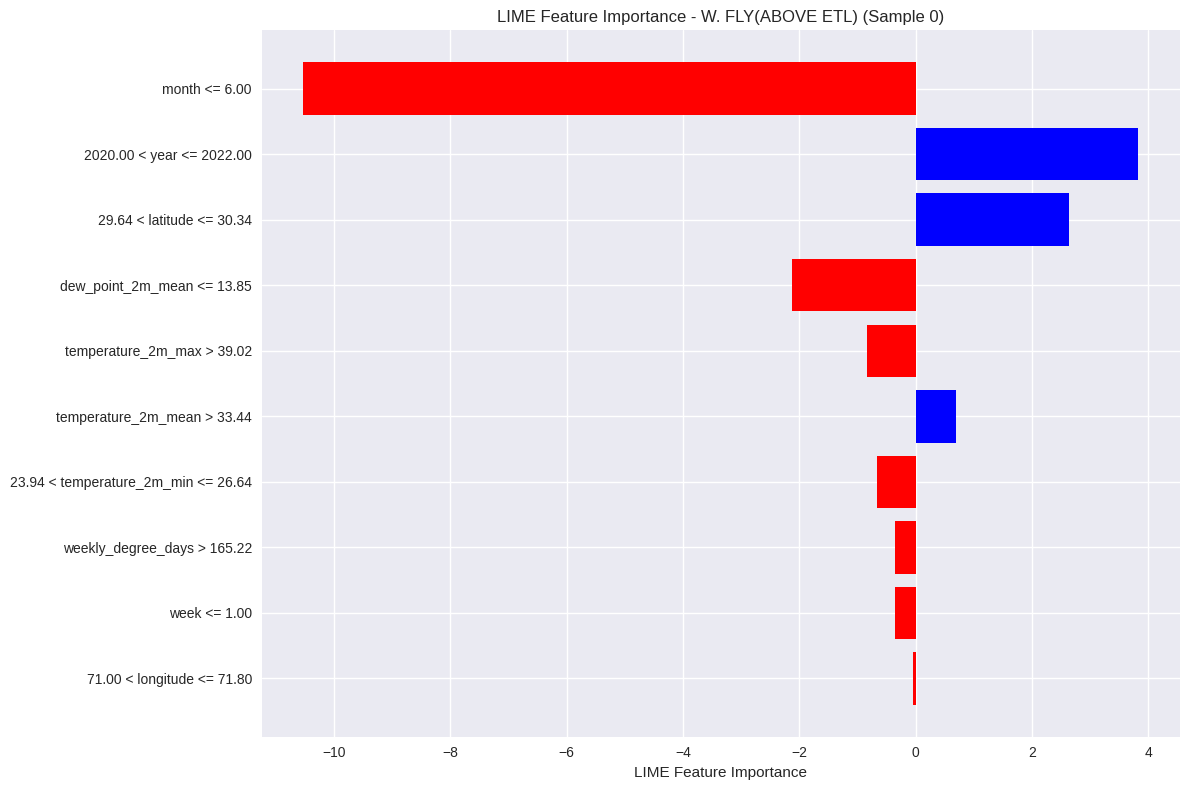


🔍 MODEL INTERPRETATION VISUALIZATIONS
1. Individual PFI plots
2. Individual SHAP plots
3. Individual LIME plots
4. PFI Heatmap (all targets)
5. SHAP Heatmap (all targets)
6. Top Features Summary (PFI vs SHAP)
7. All visualizations
0. Exit

Enter your choice (0-7): 6


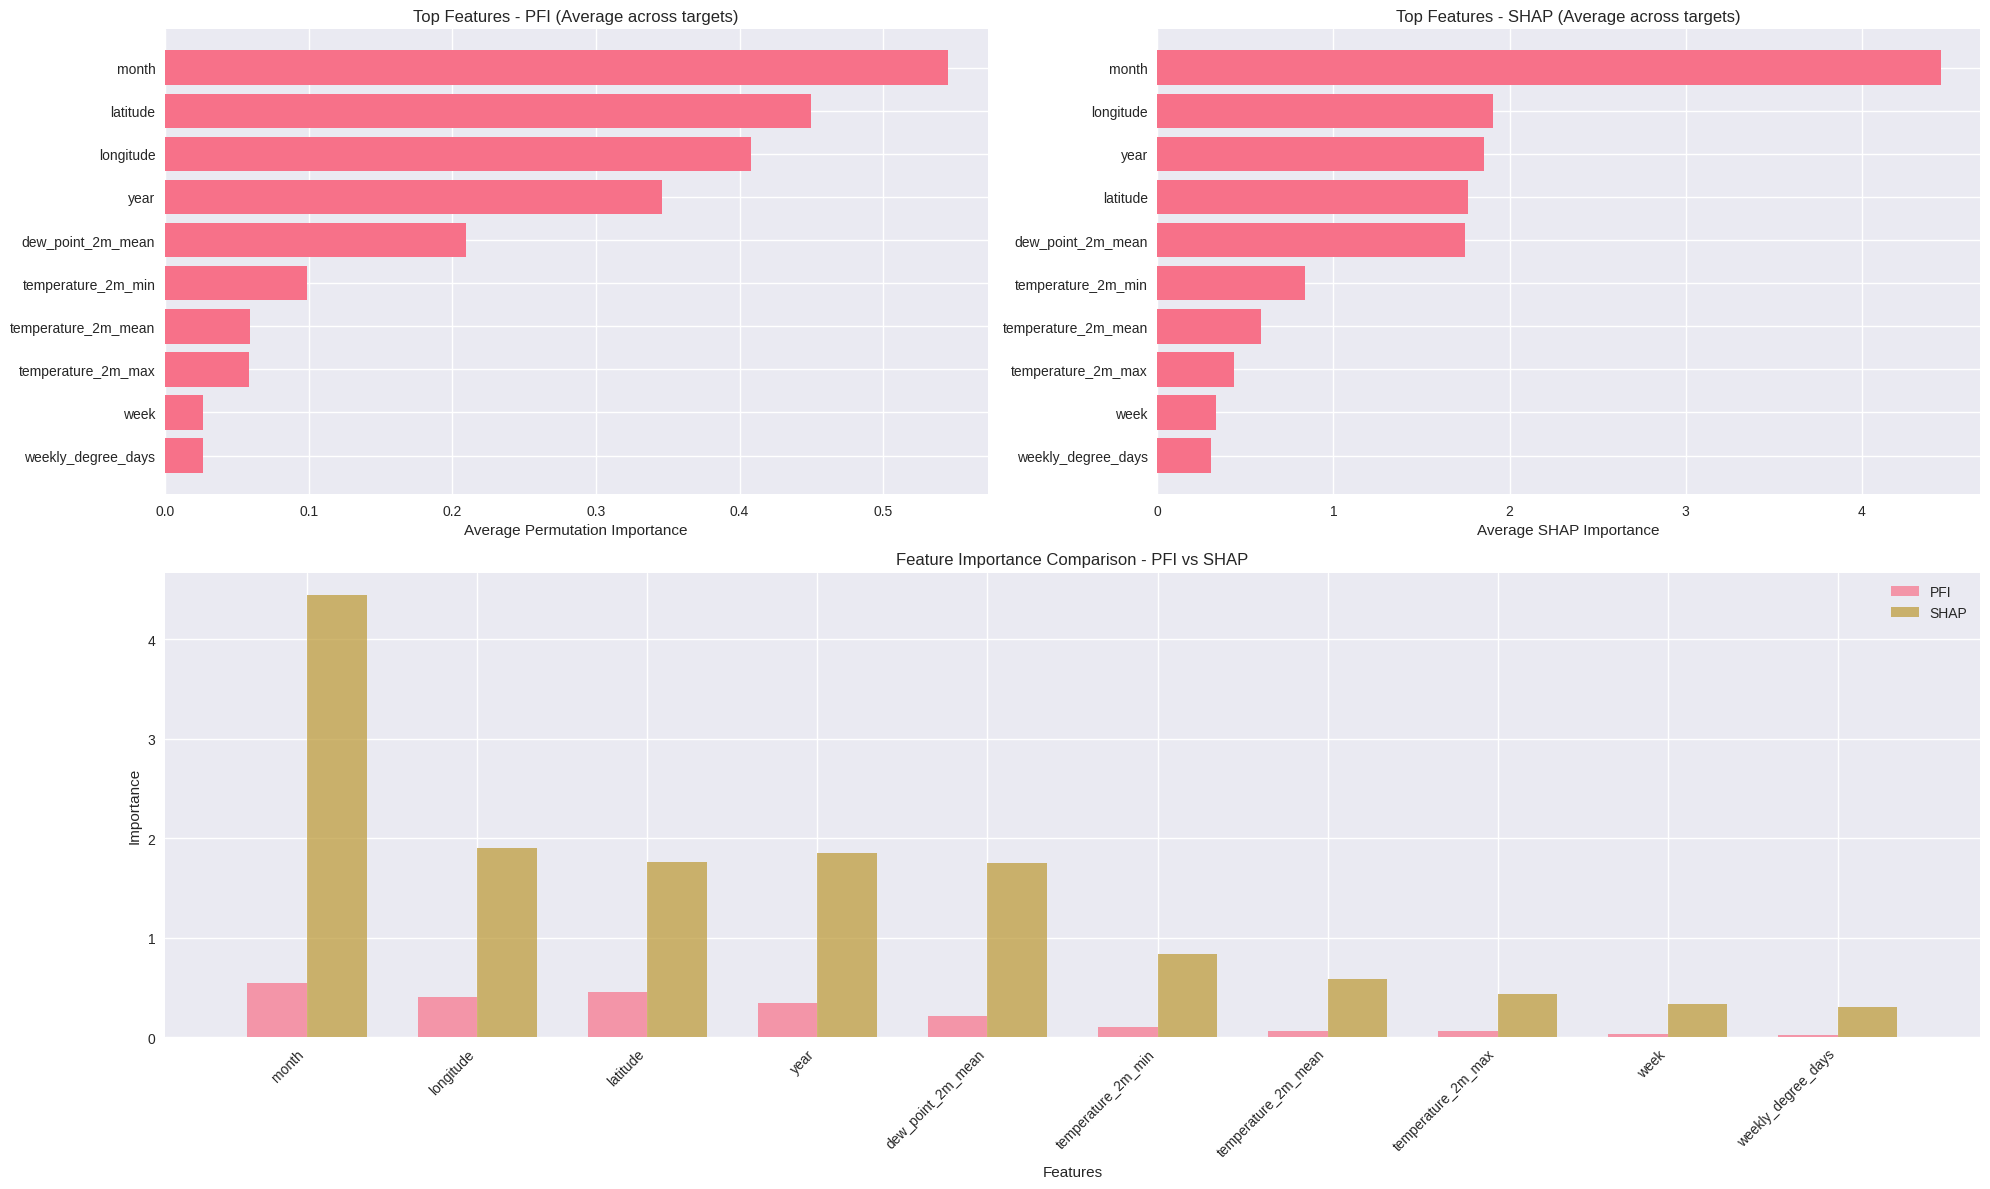


🔍 MODEL INTERPRETATION VISUALIZATIONS
1. Individual PFI plots
2. Individual SHAP plots
3. Individual LIME plots
4. PFI Heatmap (all targets)
5. SHAP Heatmap (all targets)
6. Top Features Summary (PFI vs SHAP)
7. All visualizations
0. Exit


KeyboardInterrupt: Interrupted by user

In [ ]:
import os
import shap
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lime.lime_tabular import LimeTabularExplainer
from sklearn.inspection import permutation_importance
from xgboost import XGBRegressor
import seaborn as sns
from matplotlib.gridspec import GridSpec

# Set matplotlib style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# === Load Data ===
df = pd.read_excel("final_data.xlsx")
df.fillna(0, inplace=True)
df = df.drop(columns=['TOTAL AREA VISITED', 'TOTAL SPOTS VISITED'])

target_cols = ['W. FLY(ABOVE ETL)', 'JASSID(ABOVE ETL)', 'THRIPS(ABOVE ETL)',
               'M.BUG(ABOVE ETL)', 'MITES(ABOVE ETL)', 'APHIDS(ABOVE ETL)',
               'DUSKY COTTON BUG(ABOVE ETL)', 'W. FLY(BELOW ETL)', 'JASSID(BELOW ETL)',
               'THRIPS(BELOW ETL)', 'MITES(BELOW ETL)', 'APHIDS(BELOW ETL)',
               'DUSKY COTTON BUG(BELOW ETL)', 'SBW(ABOVE ETL)', 'PBW(ABOVE ETL)',
               'ABW(ABOVE ETL)', 'Army Worm(ABOVE ETL)', 'SBW(BELOW ETL)',
               'PBW(BELOW ETL)', 'ABW(BELOW ETL)', 'CLCV(%SPOT)', 'CLCV(%AREA)',
               'WILT(%SPOT)', 'WILT(%AREA)']

X = df.drop(columns=target_cols)
y = df[target_cols]

# === Define paths ===
model_dir = "best_models"
output_dir = "model_interpretation_outputs"
os.makedirs(output_dir, exist_ok=True)

# === LIME Explainer Setup (Global) ===
lime_explainer = LimeTabularExplainer(
    training_data=X.values,
    feature_names=X.columns.tolist(),
    mode='regression',
    random_state=42
)

# === Storage for all results ===
all_pfi_results = {}
all_shap_results = {}
all_lime_results = {}

# === Loop through all target models ===
for target in target_cols:
    print(f"\n🔍 Interpreting model for target: {target}")
    model_path = os.path.join(model_dir, f"best_model_StackingRegressor_{target}.joblib")
    if not os.path.exists(model_path):
        print(f"⚠️ Skipping missing model for: {target}")
        continue

    model = joblib.load(model_path)

    # === 1. Permutation Feature Importance (PFI) ===
    print(f"  ➤ Calculating PFI...")
    pfi_result = permutation_importance(model, X, y[target], n_repeats=10, random_state=42)
    sorted_idx = pfi_result.importances_mean.argsort()[::-1]

    # Store PFI results
    all_pfi_results[target] = {
        'importances': pfi_result.importances_mean,
        'features': X.columns,
        'sorted_idx': sorted_idx
    }

    # === 2. SHAP (using XGBoost only, as surrogate model) ===
    print(f"  ➤ Training XGBoost for SHAP...")
    xgb_model = XGBRegressor(n_estimators=100, random_state=42)
    xgb_model.fit(X, y[target])

    explainer = shap.Explainer(xgb_model, X)
    shap_values = explainer(X)

    # Store SHAP results
    all_shap_results[target] = {
        'shap_values': shap_values,
        'feature_importance': np.abs(shap_values.values).mean(0)
    }

    # === 3. LIME Explanation (on 1st sample) ===
    print(f"  ➤ Running LIME on sample 0...")
    sample_idx = 0
    instance = X.iloc[sample_idx].values

    lime_exp = lime_explainer.explain_instance(
        data_row=instance,
        predict_fn=model.predict
    )

    # Extract LIME feature importance
    lime_values = lime_exp.as_list()
    lime_features = [item[0] for item in lime_values]
    lime_importance = [item[1] for item in lime_values]

    all_lime_results[target] = {
        'features': lime_features,
        'importance': lime_importance
    }

print("\n✅ All interpretation calculations completed!")

# === VISUALIZATION FUNCTIONS ===

def plot_individual_pfi(target_name, max_features=15):
    """Plot PFI for a single target"""
    data = all_pfi_results[target_name]
    top_idx = data['sorted_idx'][:max_features]

    plt.figure(figsize=(12, 8))
    plt.barh(range(len(top_idx)), data['importances'][top_idx])
    plt.yticks(range(len(top_idx)), data['features'][top_idx])
    plt.xlabel('Permutation Importance')
    plt.title(f'Permutation Feature Importance - {target_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

def plot_individual_shap(target_name, max_features=15):
    """Plot SHAP for a single target"""
    data = all_shap_results[target_name]
    sorted_idx = np.argsort(data['feature_importance'])[::-1][:max_features]

    plt.figure(figsize=(12, 8))
    plt.barh(range(len(sorted_idx)), data['feature_importance'][sorted_idx])
    plt.yticks(range(len(sorted_idx)), X.columns[sorted_idx])
    plt.xlabel('Mean |SHAP Value|')
    plt.title(f'SHAP Feature Importance - {target_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

def plot_individual_lime(target_name, max_features=15):
    """Plot LIME for a single target"""
    data = all_lime_results[target_name]
    # Sort by absolute importance
    sorted_pairs = sorted(zip(data['features'], data['importance']),
                         key=lambda x: abs(x[1]), reverse=True)[:max_features]

    features, importance = zip(*sorted_pairs)
    colors = ['red' if imp < 0 else 'blue' for imp in importance]

    plt.figure(figsize=(12, 8))
    plt.barh(range(len(features)), importance, color=colors)
    plt.yticks(range(len(features)), features)
    plt.xlabel('LIME Feature Importance')
    plt.title(f'LIME Feature Importance - {target_name} (Sample 0)')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

def plot_comparison_heatmap(method='pfi', max_features=10):
    """Create heatmap comparing feature importance across all targets"""
    if method == 'pfi':
        data_dict = all_pfi_results
        title = 'Permutation Feature Importance Across All Targets'
        ylabel = 'Permutation Importance'
    elif method == 'shap':
        data_dict = all_shap_results
        title = 'SHAP Feature Importance Across All Targets'
        ylabel = 'Mean |SHAP Value|'

    # Get top features across all targets
    all_features = set()
    for target_data in data_dict.values():
        if method == 'pfi':
            top_idx = target_data['sorted_idx'][:max_features]
            all_features.update(target_data['features'][top_idx])
        elif method == 'shap':
            sorted_idx = np.argsort(target_data['feature_importance'])[::-1][:max_features]
            all_features.update(X.columns[sorted_idx])

    # Create matrix
    feature_list = list(all_features)[:max_features]
    matrix = np.zeros((len(feature_list), len(data_dict)))

    for j, (target, target_data) in enumerate(data_dict.items()):
        for i, feature in enumerate(feature_list):
            if method == 'pfi':
                feature_idx = np.where(target_data['features'] == feature)[0]
                if len(feature_idx) > 0:
                    matrix[i, j] = target_data['importances'][feature_idx[0]]
            elif method == 'shap':
                feature_idx = np.where(X.columns == feature)[0]
                if len(feature_idx) > 0:
                    matrix[i, j] = target_data['feature_importance'][feature_idx[0]]

    plt.figure(figsize=(16, 10))
    sns.heatmap(matrix,
                xticklabels=list(data_dict.keys()),
                yticklabels=feature_list,
                annot=True,
                fmt='.3f',
                cmap='viridis',
                cbar_kws={'label': ylabel})
    plt.title(title)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

def plot_top_features_summary(max_features=10):
    """Plot top features across all methods for comparison"""
    fig = plt.figure(figsize=(20, 12))
    gs = GridSpec(2, 2, figure=fig)

    # Get most important features from each method
    pfi_features = {}
    shap_features = {}

    for target in all_pfi_results.keys():
        pfi_data = all_pfi_results[target]
        top_idx = pfi_data['sorted_idx'][:max_features]
        for idx in top_idx:
            feature = pfi_data['features'][idx]
            if feature not in pfi_features:
                pfi_features[feature] = []
            pfi_features[feature].append(pfi_data['importances'][idx])

    for target in all_shap_results.keys():
        shap_data = all_shap_results[target]
        sorted_idx = np.argsort(shap_data['feature_importance'])[::-1][:max_features]
        for idx in sorted_idx:
            feature = X.columns[idx]
            if feature not in shap_features:
                shap_features[feature] = []
            shap_features[feature].append(shap_data['feature_importance'][idx])

    # Average importance across targets
    pfi_avg = {k: np.mean(v) for k, v in pfi_features.items()}
    shap_avg = {k: np.mean(v) for k, v in shap_features.items()}

    # Sort and plot
    pfi_sorted = sorted(pfi_avg.items(), key=lambda x: x[1], reverse=True)[:max_features]
    shap_sorted = sorted(shap_avg.items(), key=lambda x: x[1], reverse=True)[:max_features]

    # PFI plot
    ax1 = fig.add_subplot(gs[0, 0])
    features, importance = zip(*pfi_sorted)
    ax1.barh(range(len(features)), importance)
    ax1.set_yticks(range(len(features)))
    ax1.set_yticklabels(features)
    ax1.set_xlabel('Average Permutation Importance')
    ax1.set_title('Top Features - PFI (Average across targets)')
    ax1.invert_yaxis()

    # SHAP plot
    ax2 = fig.add_subplot(gs[0, 1])
    features, importance = zip(*shap_sorted)
    ax2.barh(range(len(features)), importance)
    ax2.set_yticks(range(len(features)))
    ax2.set_yticklabels(features)
    ax2.set_xlabel('Average SHAP Importance')
    ax2.set_title('Top Features - SHAP (Average across targets)')
    ax2.invert_yaxis()

    # Combined comparison
    ax3 = fig.add_subplot(gs[1, :])
    all_features = set(pfi_avg.keys()) | set(shap_avg.keys())
    combined_data = []

    for feature in all_features:
        pfi_val = pfi_avg.get(feature, 0)
        shap_val = shap_avg.get(feature, 0)
        combined_data.append((feature, pfi_val, shap_val))

    combined_data = sorted(combined_data, key=lambda x: x[1] + x[2], reverse=True)[:max_features]

    features, pfi_vals, shap_vals = zip(*combined_data)
    x = np.arange(len(features))
    width = 0.35

    ax3.bar(x - width/2, pfi_vals, width, label='PFI', alpha=0.7)
    ax3.bar(x + width/2, shap_vals, width, label='SHAP', alpha=0.7)
    ax3.set_xlabel('Features')
    ax3.set_ylabel('Importance')
    ax3.set_title('Feature Importance Comparison - PFI vs SHAP')
    ax3.set_xticks(x)
    ax3.set_xticklabels(features, rotation=45, ha='right')
    ax3.legend()

    plt.tight_layout()
    plt.show()

# === INTERACTIVE MENU ===
def display_menu():
    print("\n" + "="*60)
    print("🔍 MODEL INTERPRETATION VISUALIZATIONS")
    print("="*60)
    print("1. Individual PFI plots")
    print("2. Individual SHAP plots")
    print("3. Individual LIME plots")
    print("4. PFI Heatmap (all targets)")
    print("5. SHAP Heatmap (all targets)")
    print("6. Top Features Summary (PFI vs SHAP)")
    print("7. All visualizations")
    print("0. Exit")
    print("="*60)

def main_menu():
    while True:
        display_menu()
        choice = input("\nEnter your choice (0-7): ").strip()

        if choice == '0':
            print("👋 Goodbye!")
            break
        elif choice == '1':
            print(f"\nAvailable targets: {list(all_pfi_results.keys())}")
            target = input("Enter target name: ").strip()
            if target in all_pfi_results:
                plot_individual_pfi(target)
            else:
                print("❌ Target not found!")
        elif choice == '2':
            print(f"\nAvailable targets: {list(all_shap_results.keys())}")
            target = input("Enter target name: ").strip()
            if target in all_shap_results:
                plot_individual_shap(target)
            else:
                print("❌ Target not found!")
        elif choice == '3':
            print(f"\nAvailable targets: {list(all_lime_results.keys())}")
            target = input("Enter target name: ").strip()
            if target in all_lime_results:
                plot_individual_lime(target)
            else:
                print("❌ Target not found!")
        elif choice == '4':
            plot_comparison_heatmap('pfi')
        elif choice == '5':
            plot_comparison_heatmap('shap')
        elif choice == '6':
            plot_top_features_summary()
        elif choice == '7':
            print("\n🎨 Showing all visualizations...")
            plot_comparison_heatmap('pfi')
            plot_comparison_heatmap('shap')
            plot_top_features_summary()
        else:
            print("❌ Invalid choice! Please try again.")

# === RUN INTERACTIVE MENU ===
if __name__ == "__main__":
    main_menu()

# Other Data


In [ ]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 7.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=42f14f76904fee978bde46b9b0897b018e426b4d8d050798d184e41cae831877
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


=== Decision Tree ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       311
           1       0.99      1.00      1.00       129

    accuracy                           1.00       440
   macro avg       1.00      1.00      1.00       440
weighted avg       1.00      1.00      1.00       440

=== Random Forest ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       311
           1       0.99      1.00      1.00       129

    accuracy                           1.00       440
   macro avg       1.00      1.00      1.00       440
weighted avg       1.00      1.00      1.00       440

=== SVM ===
              precision    recall  f1-score   support

           0       0.98      0.97      0.97       311
           1       0.93      0.95      0.94       129

    accuracy                           0.96       440
   macro avg       0.95      0.96      0.96       440
weighted avg      

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


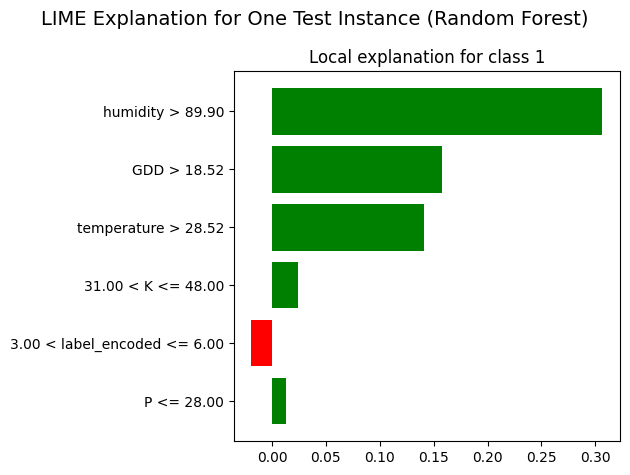

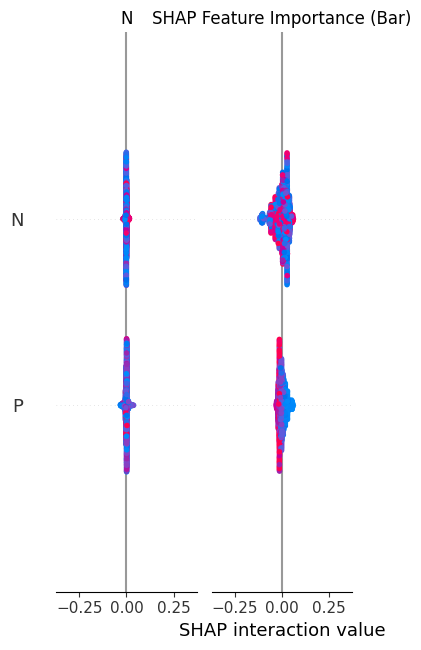

IndexError: index 1 is out of bounds for axis 0 with size 1

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
import lime.lime_tabular
import shap
import matplotlib.pyplot as plt

# 1. Load Data
df = pd.read_csv("processed_crop.csv")  # Adjust the path if needed
X = df.drop(columns=["pest"])
y = df["pest"]

# 2. Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train Models

# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_preds = dt.predict(X_test)
print("=== Decision Tree ===")
print(classification_report(y_test, dt_preds))

# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
print("=== Random Forest ===")
print(classification_report(y_test, rf_preds))

# SVM with scaling
svm = make_pipeline(StandardScaler(), SVC(probability=True))
svm.fit(X_train, y_train)
svm_preds = svm.predict(X_test)
print("=== SVM ===")
print(classification_report(y_test, svm_preds))

# 4. LIME (Random Forest, Matplotlib Plot)
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X.columns.tolist(),
    class_names=[str(c) for c in sorted(y.unique())],
    mode='classification'
)

lime_exp = explainer_lime.explain_instance(X_test.iloc[0].values, rf.predict_proba, num_features=6)

# Plot LIME with matplotlib
fig = lime_exp.as_pyplot_figure()
fig.suptitle("LIME Explanation for One Test Instance (Random Forest)", fontsize=14)
plt.tight_layout()
plt.show()

# 5. SHAP (Random Forest, Summary + Decision Plot)
explainer_shap = shap.TreeExplainer(rf)
shap_values = explainer_shap.shap_values(X_train)

# Summary plot (bar)
shap.summary_plot(shap_values, X_train, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Bar)")
plt.tight_layout()
plt.show()

# Decision plot for one test sample
instance_idx = 0
test_instance = X_test.iloc[instance_idx:instance_idx + 1]
test_shap_values = explainer_shap.shap_values(test_instance)

predicted_class = rf.predict(test_instance)[0]
class_idx = list(rf.classes_).index(predicted_class)
base_value = explainer_shap.expected_value[class_idx]
shap_val = test_shap_values[class_idx]
features_arr = test_instance.values[0]

shap.decision_plot(
    base_value,
    shap_val,
    features_arr,
    feature_names=X_test.columns.tolist(),
    show=False
)
plt.title(f"SHAP Decision Plot for Instance {instance_idx} (Class: {predicted_class})")
plt.show()


=== Decision Tree ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       636
           1       1.00      1.00      1.00       244

    accuracy                           1.00       880
   macro avg       1.00      1.00      1.00       880
weighted avg       1.00      1.00      1.00       880

=== Random Forest ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       636
           1       1.00      1.00      1.00       244

    accuracy                           1.00       880
   macro avg       1.00      1.00      1.00       880
weighted avg       1.00      1.00      1.00       880

=== SVM ===
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       636
           1       0.91      0.92      0.92       244

    accuracy                           0.95       880
   macro avg       0.94      0.94      0.94       880
weighted avg      

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


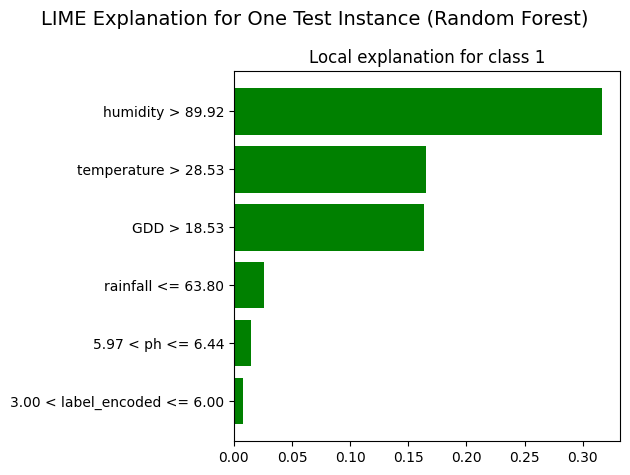

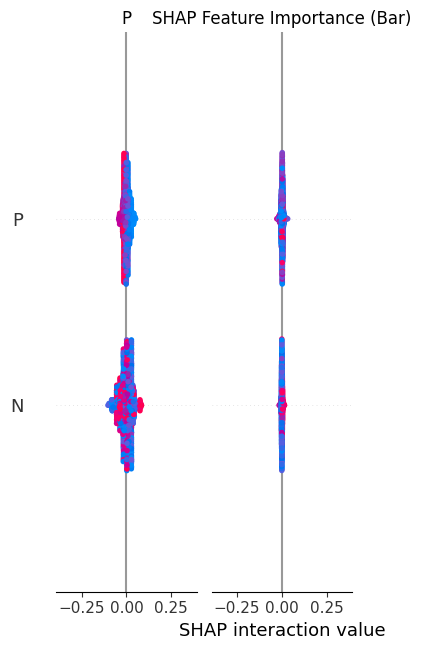


Calculating Permutation Feature Importance...


/tmp/ipython-input-42-1417054819.py:114: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/tmp/ipython-input-42-1417054819.py:114: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/tmp/ipython-input-42-1417054819.py:114: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


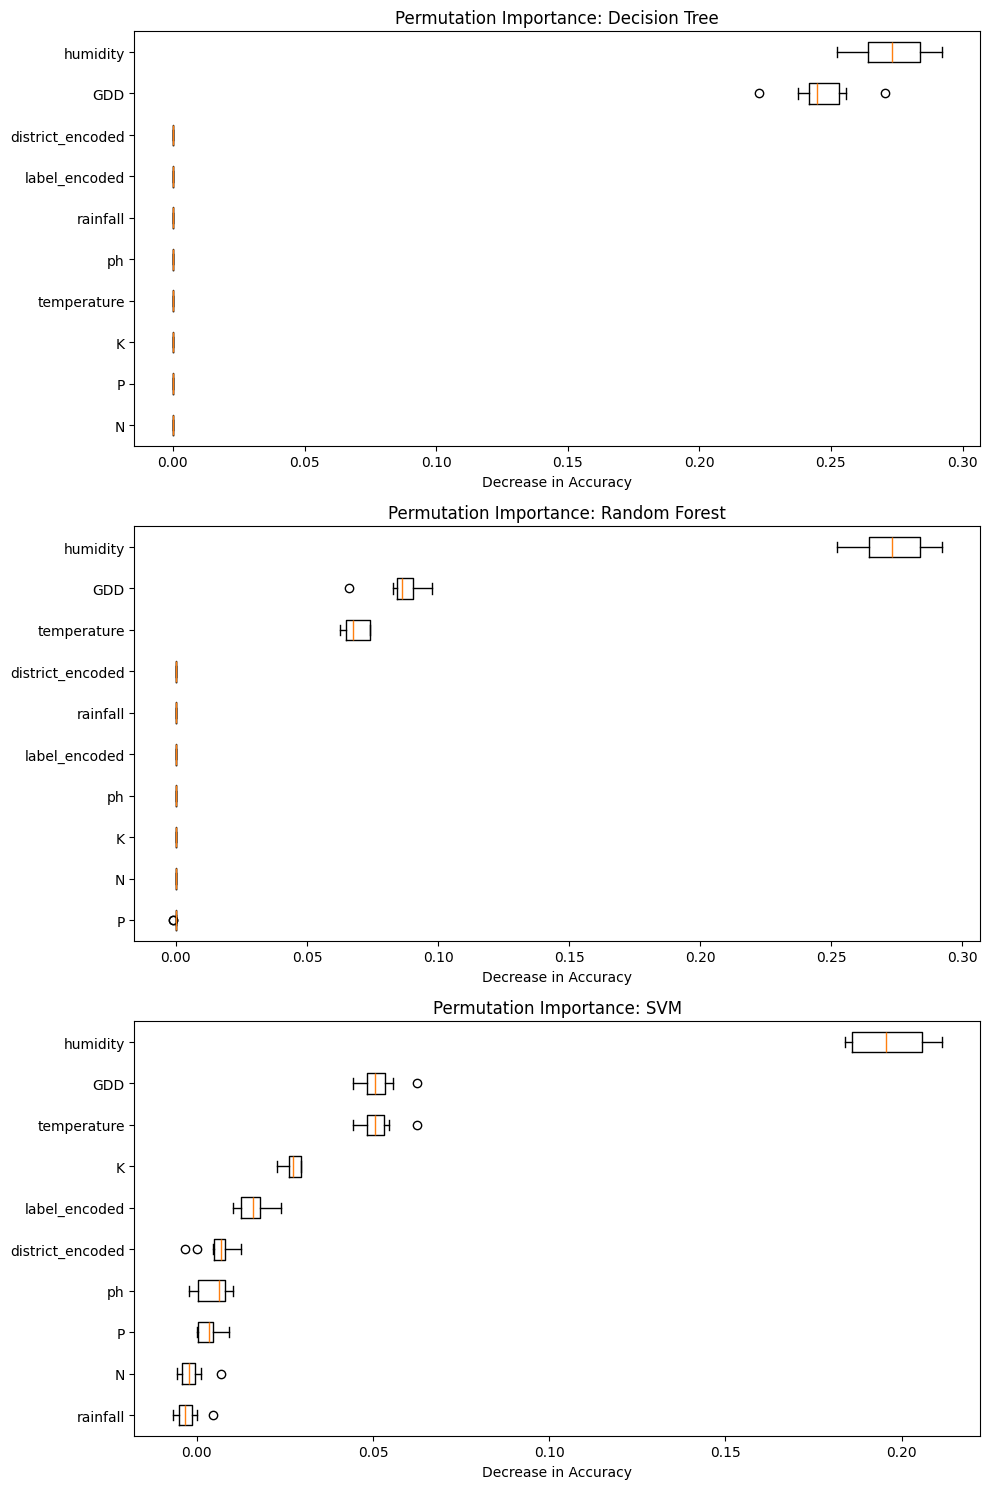


=== Top 5 Important Features ===
Decision Tree: humidity, GDD, district_encoded, label_encoded, rainfall
Random Forest: humidity, GDD, temperature, district_encoded, rainfall
SVM: humidity, GDD, temperature, K, label_encoded


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from sklearn.inspection import permutation_importance  # For PFI
import lime.lime_tabular
import shap
import matplotlib.pyplot as plt
import numpy as np

# 1. Load Data
df = pd.read_csv("processed_crop.csv")  # Adjust the path if needed
X = df.drop(columns=["pest"])
y = df["pest"]

# 2. Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

# 3. Train Models

# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_preds = dt.predict(X_test)
print("=== Decision Tree ===")
print(classification_report(y_test, dt_preds))

# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
print("=== Random Forest ===")
print(classification_report(y_test, rf_preds))

# SVM with scaling
svm = make_pipeline(StandardScaler(), SVC(probability=True))
svm.fit(X_train, y_train)
svm_preds = svm.predict(X_test)
print("=== SVM ===")
print(classification_report(y_test, svm_preds))

# 4. LIME (Random Forest, Matplotlib Plot)
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X.columns.tolist(),
    class_names=[str(c) for c in sorted(y.unique())],
    mode='classification'
)

lime_exp = explainer_lime.explain_instance(X_test.iloc[0].values, rf.predict_proba, num_features=6)

# Plot LIME with matplotlib
fig = lime_exp.as_pyplot_figure()
fig.suptitle("LIME Explanation for One Test Instance (Random Forest)", fontsize=14)
plt.tight_layout()
plt.show()

# 5. SHAP (Random Forest, Summary + Decision Plot)
explainer_shap = shap.TreeExplainer(rf)
shap_values = explainer_shap.shap_values(X_train)

# Summary plot (bar)
shap.summary_plot(shap_values, X_train, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Bar)")
plt.tight_layout()
plt.show()

# Decision plot for one test sample
instance_idx = 0
test_instance = X_test.iloc[instance_idx:instance_idx + 1]
test_shap_values = explainer_shap.shap_values(test_instance)

predicted_class = rf.predict(test_instance)[0]
class_idx = list(rf.classes_).index(predicted_class)

# Handle SHAP value structure
if isinstance(test_shap_values, list):
    # Multi-class classification
    base_value = explainer_shap.expected_value[class_idx]
    shap_val = test_shap_values[class_idx][0]  # [class_idx][0] for multi-class
else:
    # Binary classification
    if isinstance(explainer_shap.expected_value, np.ndarray):
        base_value = explainer_shap.expected_value[class_idx]
    else:
        base_value = explainer_shap.expected_value
    shap_val = test_shap_values[0]  # [0] for binary classification

features_arr = test_instance.values[0]

# shap.decision_plot(
#     base_value,
#     shap_val,
#     features_arr,
#     feature_names=X_test.columns.tolist(),
#     show=False
# )
# plt.title(f"SHAP Decision Plot for Instance {instance_idx} (Class: {predicted_class})")
# plt.tight_layout()
# plt.show()

# 6. Permutation Feature Importance (PFI) for all models
def plot_pfi(model, X, y, title, ax):
    """Calculate and plot Permutation Feature Importance"""
    result = permutation_importance(
        model, X, y, n_repeats=10, random_state=42, n_jobs=-1
    )
    sorted_idx = result.importances_mean.argsort()

    ax.boxplot(
        result.importances[sorted_idx].T,
        vert=False,
        labels=X.columns[sorted_idx]
    )
    ax.set_title(f"Permutation Importance: {title}")
    ax.set_xlabel("Decrease in Accuracy")
    fig.tight_layout()
    return result

# Create a figure for PFI plots
fig, axes = plt.subplots(3, 1, figsize=(10, 15))

# Calculate and plot PFI for each model
print("\nCalculating Permutation Feature Importance...")
pfi_dt = plot_pfi(dt, X_test, y_test, "Decision Tree", axes[0])
pfi_rf = plot_pfi(rf, X_test, y_test, "Random Forest", axes[1])
pfi_svm = plot_pfi(svm, X_test, y_test, "SVM", axes[2])

plt.tight_layout()
plt.show()

# 7. Compare top features across models
def get_top_features(result, feature_names, n=5):
    """Get top n features from PFI results"""
    sorted_idx = result.importances_mean.argsort()[::-1]  # Descending order
    return [feature_names[i] for i in sorted_idx[:n]]

top_dt = get_top_features(pfi_dt, X.columns)
top_rf = get_top_features(pfi_rf, X.columns)
top_svm = get_top_features(pfi_svm, X.columns)

print("\n=== Top 5 Important Features ===")
print(f"Decision Tree: {', '.join(top_dt)}")
print(f"Random Forest: {', '.join(top_rf)}")
print(f"SVM: {', '.join(top_svm)}")

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from sklearn.inspection import permutation_importance
import lime.lime_tabular
import shap
import matplotlib.pyplot as plt
import numpy as np
import os
from datetime import datetime
from io import StringIO

# Create output directory with timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_dir = f"model_analysis_{timestamp}"
os.makedirs(output_dir, exist_ok=True)

# 1. Load Data
df = pd.read_csv("processed_crop.csv")
X = df.drop(columns=["pest"])
y = df["pest"]

# 2. Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

# 3. Train Models and save reports as CSV
performance_data = []

# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_preds = dt.predict(X_test)
dt_report = classification_report(y_test, dt_preds, output_dict=True)
dt_df = pd.DataFrame(dt_report).transpose()
dt_df.to_csv(f"{output_dir}/decision_tree_performance.csv")

# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
rf_report = classification_report(y_test, rf_preds, output_dict=True)
rf_df = pd.DataFrame(rf_report).transpose()
rf_df.to_csv(f"{output_dir}/random_forest_performance.csv")

# SVM with scaling
svm = make_pipeline(StandardScaler(), SVC(probability=True))
svm.fit(X_train, y_train)
svm_preds = svm.predict(X_test)
svm_report = classification_report(y_test, svm_preds, output_dict=True)
svm_df = pd.DataFrame(svm_report).transpose()
svm_df.to_csv(f"{output_dir}/svm_performance.csv")

# 4. LIME (Random Forest)
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X.columns.tolist(),
    class_names=[str(c) for c in sorted(y.unique())],
    mode='classification'
)

lime_exp = explainer_lime.explain_instance(X_test.iloc[0].values, rf.predict_proba, num_features=6)

# Save LIME plot
fig = lime_exp.as_pyplot_figure()
fig.suptitle("LIME Explanation for One Test Instance (Random Forest)", fontsize=14)
plt.tight_layout()
plt.savefig(f"{output_dir}/lime_explanation.png", dpi=300, bbox_inches='tight')
plt.close()

# Save LIME explanation as CSV
lime_data = []
for feature, weight in lime_exp.as_list():
    lime_data.append({"Feature": feature, "Weight": weight})
pd.DataFrame(lime_data).to_csv(f"{output_dir}/lime_explanation.csv", index=False)

# 5. SHAP (Random Forest)
explainer_shap = shap.TreeExplainer(rf)
shap_values = explainer_shap.shap_values(X_train)

# Save SHAP summary plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_train, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Bar)")
plt.tight_layout()
plt.savefig(f"{output_dir}/shap_summary.png", dpi=300, bbox_inches='tight')
plt.close()

# Save SHAP values as CSV
if isinstance(shap_values, list):
    # Multi-class case
    for i, class_shap in enumerate(shap_values):
        pd.DataFrame(class_shap, columns=X.columns).to_csv(f"{output_dir}/shap_values_class_{i}.csv", index=False)
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    # 3D binary case
    n_classes = shap_values.shape[2]
    for i in range(n_classes):
        pd.DataFrame(shap_values[:, :, i], columns=X.columns).to_csv(f"{output_dir}/shap_values_class_{i}.csv", index=False)
else:
    # Binary classification (2D)
    pd.DataFrame(shap_values, columns=X.columns).to_csv(f"{output_dir}/shap_values.csv", index=False)

# Save SHAP decision plot (for first instance)
test_instance = X_test.iloc[0:1]
test_shap_values = explainer_shap.shap_values(test_instance)
predicted_class = rf.predict(test_instance)[0]
class_idx = list(rf.classes_).index(predicted_class)

if isinstance(test_shap_values, list):
    base_value = explainer_shap.expected_value[class_idx]
    shap_val = test_shap_values[class_idx][0]
else:
    if isinstance(explainer_shap.expected_value, np.ndarray):
        base_value = explainer_shap.expected_value[class_idx]
    else:
        base_value = explainer_shap.expected_value
    shap_val = test_shap_values[0]

# Ensure correct format for SHAP decision plot
plt.figure(figsize=(10, 6))


# Save decision plot data as CSV
decision_data = []
for i, (feature, value, shap_value) in enumerate(zip(X_test.columns, test_instance.values[0], shap_val)):
    decision_data.append({
        "Feature": feature,
        "Feature Value": value,
        "SHAP Value": shap_value,
        "Absolute SHAP": abs(shap_value)
    })
pd.DataFrame(decision_data).to_csv(f"{output_dir}/shap_decision_data.csv", index=False)

# 6. Permutation Feature Importance (PFI) for all models
def save_pfi(model, X, y, title, filename):
    """Calculate, plot and save Permutation Feature Importance"""
    result = permutation_importance(
        model, X, y, n_repeats=10, random_state=42, n_jobs=-1
    )
    sorted_idx = result.importances_mean.argsort()

    # Save plot
    plt.figure(figsize=(10, 6))
    plt.boxplot(
        result.importances[sorted_idx].T,
        vert=False,
        labels=X.columns[sorted_idx]
    )
    plt.title(f"Permutation Importance: {title}")
    plt.xlabel("Decrease in Accuracy")
    plt.tight_layout()
    plt.savefig(f"{output_dir}/{filename}.png", dpi=300, bbox_inches='tight')
    plt.close()

    # Save data as CSV
    pfi_data = []
    for i in sorted_idx:
        pfi_data.append({
            "Feature": X.columns[i],
            "Mean Importance": result.importances_mean[i],
            "Std Importance": result.importances_std[i],
            "All Values": result.importances[i]
        })
    pd.DataFrame(pfi_data).to_csv(f"{output_dir}/{filename}.csv", index=False)
    return result

# Calculate and save PFI for each model
print("\nCalculating Permutation Feature Importance...")
pfi_dt = save_pfi(dt, X_test, y_test, "Decision Tree", "pfi_decision_tree")
pfi_rf = save_pfi(rf, X_test, y_test, "Random Forest", "pfi_random_forest")
pfi_svm = save_pfi(svm, X_test, y_test, "SVM", "pfi_svm")

# 7. Save top features comparison as CSV
def get_top_features(result, feature_names, n=5):
    sorted_idx = result.importances_mean.argsort()[::-1]
    return [(feature_names[i], result.importances_mean[i], result.importances_std[i]) for i in sorted_idx[:n]]

top_features_data = []
for model_name, result in [("Decision Tree", pfi_dt),
                          ("Random Forest", pfi_rf),
                          ("SVM", pfi_svm)]:
    features = get_top_features(result, X.columns)
    for rank, (feature, mean, std) in enumerate(features, 1):
        top_features_data.append({
            "Model": model_name,
            "Rank": rank,
            "Feature": feature,
            "Mean Importance": mean,
            "Std Importance": std
        })

pd.DataFrame(top_features_data).to_csv(f"{output_dir}/top_features.csv", index=False)

print(f"\nAll results and visualizations saved to: {output_dir}")

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(



Calculating Permutation Feature Importance...


/tmp/ipython-input-51-2672404516.py:148: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(
/tmp/ipython-input-51-2672404516.py:148: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(
/tmp/ipython-input-51-2672404516.py:148: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(



All results and visualizations saved to: model_analysis_20250708_154026


<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

In [63]:
import shutil
from google.colab import files

# Folder to zip
folder_name = "model_explainability_20250708_160621"

# Create zip file
shutil.make_archive(folder_name, 'zip', folder_name)

# Download the zip file
files.download(f"{folder_name}.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [60]:
import os
import zipfile
import warnings
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    r2_score, accuracy_score, f1_score, precision_score,
    recall_score, roc_auc_score
)
from sklearn.base import clone
from sklearn.ensemble import (
    RandomForestClassifier, AdaBoostClassifier, BaggingClassifier,
    StackingClassifier, VotingClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from joblib import Parallel, delayed

warnings.filterwarnings("ignore")

# === Create output directory ===
output_dir = "model_outputs"
os.makedirs(output_dir, exist_ok=True)

# === Load dataset ===
df = pd.read_csv("processed_crop.csv")
X = df.drop(columns=["pest"])
y = df["pest"]

# === Random states for robustness ===
random_states = [0, 21, 42, 77, 101]
all_model_results = []

# === Define models ===
models = {
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=42),
    "GaussianNB": GaussianNB(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True),
    "XGBoost": XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric="logloss", random_state=42),
    "VotingClassifier": VotingClassifier(estimators=[
        ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
        ('xgb', XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric="logloss", random_state=42)),
        ('ada', AdaBoostClassifier(n_estimators=100, random_state=42))
    ], voting='soft'),
    "BaggingClassifier": BaggingClassifier(
        estimator=DecisionTreeClassifier(),
        n_estimators=50,
        random_state=42
    ),
    "StackingClassifier": StackingClassifier(
        estimators=[
            ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
            ('xgb', XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric="logloss", random_state=42)),
            ('ada', AdaBoostClassifier(n_estimators=100, random_state=42))
        ],
        final_estimator=LogisticRegression(),
        cv=3
    ),
    "GDD_Rule_Based": LogisticRegression()  # Placeholder
}

# === Helper function ===
def evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred, average="macro"),
        "Precision": precision_score(y_test, y_pred, average="macro"),
        "Recall": recall_score(y_test, y_pred, average="macro"),
        "ROC AUC": roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan,
        "R2 Score": r2_score(y_test, y_pred)
    }

# === Train & evaluate ===
for model_name, base_model in models.items():
    print(f"\n🚀 Training: {model_name}")
    model_metrics = []

    for rnd in random_states:
        print(f"  🔁 Random State: {rnd}")
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=rnd)

        metrics = evaluate_model(clone(base_model), X_train, y_train, X_test, y_test)
        metrics["RandomState"] = rnd
        model_metrics.append(metrics)

    df_metrics = pd.DataFrame(model_metrics)
    df_metrics["Model"] = model_name
    all_model_results.append(df_metrics)

    # Save individual model results
    df_metrics.to_csv(f"{output_dir}/{model_name}_metrics.csv", index=False)
    print(f"✅ Saved: {output_dir}/{model_name}_metrics.csv")

# === Combine and save all ===
combined = pd.concat(all_model_results, ignore_index=True)
combined.to_csv(f"{output_dir}/all_model_results.csv", index=False)

# === Summary ===
summary = combined.groupby("Model").agg({
    "Accuracy": ["mean", "std"],
    "F1 Score": ["mean", "std"],
    "Precision": ["mean", "std"],
    "Recall": ["mean", "std"],
    "ROC AUC": ["mean", "std"],
    "R2 Score": ["mean", "std"]
}).round(4)

summary.to_csv(f"{output_dir}/model_performance_summary.csv")

print("\n📊 Model Performance Summary:")
print(summary.sort_values(("F1 Score", "mean"), ascending=False))

# === Zip the results ===
zip_path = "model_outputs.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    for root, _, files in os.walk(output_dir):
        for file in files:
            filepath = os.path.join(root, file)
            zipf.write(filepath, os.path.relpath(filepath, output_dir))

print(f"\n🗜️ All results zipped at: {zip_path}")



🚀 Training: RandomForest
  🔁 Random State: 0
  🔁 Random State: 21
  🔁 Random State: 42
  🔁 Random State: 77
  🔁 Random State: 101
✅ Saved: model_outputs/RandomForest_metrics.csv

🚀 Training: DecisionTree
  🔁 Random State: 0
  🔁 Random State: 21
  🔁 Random State: 42
  🔁 Random State: 77
  🔁 Random State: 101
✅ Saved: model_outputs/DecisionTree_metrics.csv

🚀 Training: AdaBoost
  🔁 Random State: 0
  🔁 Random State: 21
  🔁 Random State: 42
  🔁 Random State: 77
  🔁 Random State: 101
✅ Saved: model_outputs/AdaBoost_metrics.csv

🚀 Training: GaussianNB
  🔁 Random State: 0
  🔁 Random State: 21
  🔁 Random State: 42
  🔁 Random State: 77
  🔁 Random State: 101
✅ Saved: model_outputs/GaussianNB_metrics.csv

🚀 Training: KNN
  🔁 Random State: 0
  🔁 Random State: 21
  🔁 Random State: 42
  🔁 Random State: 77
  🔁 Random State: 101
✅ Saved: model_outputs/KNN_metrics.csv

🚀 Training: SVM
  🔁 Random State: 0
  🔁 Random State: 21
  🔁 Random State: 42
  🔁 Random State: 77
  🔁 Random State: 101
✅ Saved: mode

In [61]:
import os
import shap
import lime.lime_tabular
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from datetime import datetime

from sklearn.ensemble import (
    RandomForestClassifier, AdaBoostClassifier,
    BaggingClassifier, StackingClassifier, VotingClassifier
)
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

# === Load and Split Data ===
df = pd.read_csv("processed_crop.csv")
X = df.drop(columns=["pest"])
y = df["pest"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# === Output Folder ===
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_dir = f"model_explainability_{timestamp}"
os.makedirs(output_dir, exist_ok=True)

# === Define Models ===
models = {
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=42),
    "GaussianNB": GaussianNB(),
    "SVM": make_pipeline(StandardScaler(), SVC(probability=True)),
    "KNN": KNeighborsClassifier(),
    "XGBoost": XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric='logloss'),
    "BaggingClassifier": BaggingClassifier(DecisionTreeClassifier(), n_estimators=50),
    "StackingClassifier": StackingClassifier(
        estimators=[
            ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
            ('xgb', XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric='logloss')),
            ('ada', AdaBoostClassifier(n_estimators=100, random_state=42))
        ],
        final_estimator=LogisticRegression()
    ),
    "VotingClassifier": VotingClassifier([
        ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
        ('xgb', XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric='logloss')),
        ('ada', AdaBoostClassifier(n_estimators=100, random_state=42))
    ], voting='soft')
}

# === Explainability Pipeline ===
def explain_model(name, model):
    print(f"\n🔍 Explaining {name}...")

    model.fit(X_train, y_train)

    # === SHAP (Tree-based only) ===
    if name in ["RandomForest", "DecisionTree", "XGBoost", "AdaBoost"]:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_test)

        plt.figure()
        shap.summary_plot(shap_values, X_test, show=False, plot_type="bar")
        plt.title(f"SHAP Summary ({name})")
        plt.tight_layout()
        plt.savefig(f"{output_dir}/{name}_shap_summary.png", dpi=300)
        plt.close()

        print(f"✅ SHAP summary saved for {name}")

    # === LIME (for first instance) ===
    lime_explainer = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_train.values,
        feature_names=X.columns.tolist(),
        class_names=[str(c) for c in sorted(y.unique())],
        mode='classification'
    )
    lime_exp = lime_explainer.explain_instance(
        X_test.iloc[0].values, model.predict_proba, num_features=5
    )
    fig = lime_exp.as_pyplot_figure()
    fig.suptitle(f"LIME Explanation ({name})", fontsize=14)
    plt.tight_layout()
    plt.savefig(f"{output_dir}/{name}_lime.png", dpi=300)
    plt.close()
    print(f"✅ LIME explanation saved for {name}")

    # === Permutation Feature Importance ===
    result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
    sorted_idx = result.importances_mean.argsort()

    plt.figure(figsize=(10, 6))
    plt.boxplot(result.importances[sorted_idx].T, vert=False, labels=X.columns[sorted_idx])
    plt.title(f"Permutation Importance ({name})")
    plt.xlabel("Decrease in Accuracy")
    plt.tight_layout()
    plt.savefig(f"{output_dir}/{name}_pfi.png", dpi=300)
    plt.close()
    print(f"✅ PFI plot saved for {name}")

    # Save PFI as CSV
    pfi_df = pd.DataFrame({
        "Feature": X.columns,
        "Mean Importance": result.importances_mean,
        "Std Importance": result.importances_std
    })
    pfi_df.to_csv(f"{output_dir}/{name}_pfi.csv", index=False)

# === Run for All Models ===
for name, model in models.items():
    try:
        explain_model(name, model)
    except Exception as e:
        print(f"⚠️ Failed on {name}: {e}")

# === Zip Outputs ===
import zipfile
zip_path = f"{output_dir}.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    for root, _, files in os.walk(output_dir):
        for file in files:
            full_path = os.path.join(root, file)
            arcname = os.path.relpath(full_path, output_dir)
            zipf.write(full_path, arcname)

print(f"\n📦 All results zipped at: {zip_path}")



🔍 Explaining RandomForest...
✅ SHAP summary saved for RandomForest
✅ LIME explanation saved for RandomForest
✅ PFI plot saved for RandomForest

🔍 Explaining DecisionTree...
✅ SHAP summary saved for DecisionTree
✅ LIME explanation saved for DecisionTree
✅ PFI plot saved for DecisionTree

🔍 Explaining AdaBoost...
⚠️ Failed on AdaBoost: Model type not yet supported by TreeExplainer: <class 'sklearn.ensemble._weight_boosting.AdaBoostClassifier'>

🔍 Explaining GaussianNB...
✅ LIME explanation saved for GaussianNB
✅ PFI plot saved for GaussianNB

🔍 Explaining SVM...
✅ LIME explanation saved for SVM
✅ PFI plot saved for SVM

🔍 Explaining KNN...
✅ LIME explanation saved for KNN
✅ PFI plot saved for KNN

🔍 Explaining XGBoost...
✅ SHAP summary saved for XGBoost
✅ LIME explanation saved for XGBoost
✅ PFI plot saved for XGBoost

🔍 Explaining BaggingClassifier...
✅ LIME explanation saved for BaggingClassifier
✅ PFI plot saved for BaggingClassifier

🔍 Explaining StackingClassifier...
✅ LIME explana

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>